In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
!pip install catboost > /dev/null
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import time
import random
from datetime import datetime, timedelta
import ipaddress
print('All libraries imported successfully')

All libraries imported successfully


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
!wget -O cicids2017_cleaned.csv "https://raw.githubusercontent.com/joolsa/CICIDS2017-Cleaned/main/cicids2017_cleaned.csv"

--2026-06-18 10:10:38--  https://raw.githubusercontent.com/joolsa/CICIDS2017-Cleaned/main/cicids2017_cleaned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-18 10:10:38 ERROR 404: Not Found.



In [4]:
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 11

SOC_COLORS = {
    'critical': '#ff4444',
    'high': '#ff8c00',
    'medium': '#ffd700',
    'low': '#00ff88',
    'info': '#00bfff',
    'bg': '#0d1117',
    'card': '#161b22',
    'border': '#30363d',
    'text': '#e6edf3',
    'muted': '#8b949e',
    'accent': '#238636',
    'purple': '#7c3aed',
    'cyan': '#22d3ee'
}

PALETTE = [SOC_COLORS['critical'], SOC_COLORS['info'], SOC_COLORS['low'],
           SOC_COLORS['medium'], SOC_COLORS['high'], SOC_COLORS['purple'], SOC_COLORS['cyan']]

print('SOC Dashboard theme configured')

SOC Dashboard theme configured


In [5]:
print('=' * 70)
print('   AI-POWERED SECURITY OPERATIONS CENTER (SOC) SIMULATOR')
print('   Intelligent Threat Detection and Response System')
print('=' * 70)
print()

INPUT_DIR = '/kaggle/input/'
print(f'Scanning Kaggle input directory: {INPUT_DIR}')
print()

available_folders = []
all_csv_files = []

if os.path.exists(INPUT_DIR):
    for root, dirs, files in os.walk(INPUT_DIR):
        rel_root = os.path.relpath(root, INPUT_DIR)
        if rel_root != '.' and root == os.path.join(INPUT_DIR, rel_root.split(os.sep)[0]):
            folder_name = rel_root.split(os.sep)[0]
            if folder_name not in available_folders:
                available_folders.append(folder_name)
        for f in files:
            full_path = os.path.join(root, f)
            if f.endswith('.csv'):
                all_csv_files.append(full_path)
                print(f'  CSV Found: {full_path}')

print()
print(f'Available Dataset Folders ({len(available_folders)}): {available_folders}')
print(f'Total CSV Files Found: {len(all_csv_files)}')

DATASET_PATH = None
PRIORITY_KEYWORDS = ['cicids', 'network', 'intrusion', 'ids', 'attack', 'blue', 'log', 'nsl', 'kdd', 'traffic']

for keyword in PRIORITY_KEYWORDS:
    for csv_path in all_csv_files:
        if keyword.lower() in csv_path.lower():
            DATASET_PATH = csv_path
            break
    if DATASET_PATH:
        break

if not DATASET_PATH and all_csv_files:
    sizes = [(os.path.getsize(p), p) for p in all_csv_files]
    sizes.sort(reverse=True)
    DATASET_PATH = sizes[0][1]

USE_SYNTHETIC = False
if not DATASET_PATH:
    USE_SYNTHETIC = True
    print()
    print('No CSV dataset found. Generating synthetic cybersecurity dataset.')
else:
    print()
    print(f'Selected Dataset: {DATASET_PATH}')
    print(f'File Size: {os.path.getsize(DATASET_PATH) / (1024*1024):.2f} MB')

   AI-POWERED SECURITY OPERATIONS CENTER (SOC) SIMULATOR
   Intelligent Threat Detection and Response System

Scanning Kaggle input directory: /kaggle/input/


Available Dataset Folders (0): []
Total CSV Files Found: 0

No CSV dataset found. Generating synthetic cybersecurity dataset.


In [6]:
def generate_synthetic_soc_dataset(n_samples=150000):
    np.random.seed(42)
    random.seed(42)

    attack_types = {
        'BENIGN': 0.645,
        'DoS Hulk': 0.07,
        'PortScan': 0.06,
        'DDoS': 0.05,
        'DoS GoldenEye': 0.04,
        'FTP-Patator': 0.03,
        'SSH-Patator': 0.03,
        'DoS slowloris': 0.02,
        'DoS Slowhttptest': 0.02,
        'Bot': 0.02,
        'Web Attack Brute Force': 0.005,
        'Web Attack XSS': 0.004,
        'Infiltration': 0.003,
        'Web Attack Sql Injection': 0.002,
        'Heartbleed': 0.001
    }

    labels = np.random.choice(
        list(attack_types.keys()),
        size=n_samples,
        p=list(attack_types.values())
    )

    benign_mask = labels == 'BENIGN'
    n_benign = benign_mask.sum()
    n_attack = n_samples - n_benign

    flow_duration = np.where(benign_mask,
        np.random.exponential(50000, n_samples),
        np.random.exponential(5000, n_samples)
    )

    fwd_packets = np.where(benign_mask,
        np.random.poisson(15, n_samples),
        np.random.poisson(500, n_samples)
    )
    bwd_packets = np.where(benign_mask,
        np.random.poisson(10, n_samples),
        np.random.poisson(50, n_samples)
    )

    fwd_pkt_len = np.where(benign_mask,
        np.abs(np.random.normal(500, 200, n_samples)),
        np.abs(np.random.normal(100, 50, n_samples))
    )
    bwd_pkt_len = np.where(benign_mask,
        np.abs(np.random.normal(400, 150, n_samples)),
        np.abs(np.random.normal(80, 30, n_samples))
    )

    flow_bytes_s = np.where(benign_mask,
        np.abs(np.random.normal(5000, 3000, n_samples)),
        np.abs(np.random.normal(500000, 200000, n_samples))
    )
    flow_pkts_s = np.where(benign_mask,
        np.abs(np.random.normal(50, 30, n_samples)),
        np.abs(np.random.normal(5000, 2000, n_samples))
    )

    fin_flag = np.random.binomial(1, np.where(benign_mask, 0.8, 0.1), n_samples)
    syn_flag = np.random.binomial(1, np.where(benign_mask, 0.3, 0.9), n_samples)
    rst_flag = np.random.binomial(1, np.where(benign_mask, 0.05, 0.4), n_samples)
    psh_flag = np.random.binomial(1, np.where(benign_mask, 0.6, 0.2), n_samples)
    ack_flag = np.random.binomial(1, np.where(benign_mask, 0.85, 0.3), n_samples)

    active_mean = np.where(benign_mask,
        np.abs(np.random.normal(200000, 100000, n_samples)),
        np.abs(np.random.normal(5000, 3000, n_samples))
    )
    idle_mean = np.where(benign_mask,
        np.abs(np.random.normal(50000, 30000, n_samples)),
        np.abs(np.random.normal(1000, 500, n_samples))
    )

    iat_mean = np.where(benign_mask,
        np.abs(np.random.normal(10000, 5000, n_samples)),
        np.abs(np.random.normal(500, 200, n_samples))
    )
    iat_std = np.abs(np.random.normal(iat_mean * 0.5, iat_mean * 0.1))

    dst_port = np.random.choice(
        [80, 443, 22, 21, 25, 53, 8080, 3389, 3306, 1433, 445, 139, np.random.randint(1024, 65535)],
        size=n_samples
    )
    src_port = np.random.randint(1024, 65535, n_samples)
    protocol = np.random.choice([6, 17, 1], size=n_samples, p=[0.7, 0.25, 0.05])

    df = pd.DataFrame({
        'Destination Port': dst_port,
        'Source Port': src_port,
        'Protocol': protocol,
        'Flow Duration': flow_duration,
        'Total Fwd Packets': fwd_packets,
        'Total Backward Packets': bwd_packets,
        'Total Length of Fwd Packets': fwd_pkt_len * fwd_packets,
        'Total Length of Bwd Packets': bwd_pkt_len * bwd_packets,
        'Fwd Packet Length Max': fwd_pkt_len * np.random.uniform(1.2, 2.0, n_samples),
        'Fwd Packet Length Min': fwd_pkt_len * np.random.uniform(0.1, 0.5, n_samples),
        'Fwd Packet Length Mean': fwd_pkt_len,
        'Fwd Packet Length Std': fwd_pkt_len * np.random.uniform(0.1, 0.4, n_samples),
        'Bwd Packet Length Max': bwd_pkt_len * np.random.uniform(1.2, 2.0, n_samples),
        'Bwd Packet Length Min': bwd_pkt_len * np.random.uniform(0.1, 0.5, n_samples),
        'Bwd Packet Length Mean': bwd_pkt_len,
        'Bwd Packet Length Std': bwd_pkt_len * np.random.uniform(0.1, 0.4, n_samples),
        'Flow Bytes/s': flow_bytes_s,
        'Flow Packets/s': flow_pkts_s,
        'Flow IAT Mean': iat_mean,
        'Flow IAT Std': iat_std,
        'Flow IAT Max': iat_mean * np.random.uniform(2, 5, n_samples),
        'Flow IAT Min': iat_mean * np.random.uniform(0.01, 0.2, n_samples),
        'Fwd IAT Total': iat_mean * fwd_packets,
        'Fwd IAT Mean': iat_mean,
        'Fwd IAT Std': iat_std * 0.8,
        'Fwd IAT Max': iat_mean * np.random.uniform(1.5, 4, n_samples),
        'Fwd IAT Min': iat_mean * np.random.uniform(0.01, 0.1, n_samples),
        'Bwd IAT Total': iat_mean * bwd_packets * 1.2,
        'Bwd IAT Mean': iat_mean * 1.1,
        'Bwd IAT Std': iat_std,
        'Bwd IAT Max': iat_mean * np.random.uniform(2, 6, n_samples),
        'Bwd IAT Min': iat_mean * np.random.uniform(0.01, 0.15, n_samples),
        'Fwd PSH Flags': psh_flag,
        'Bwd PSH Flags': np.random.binomial(1, 0.3, n_samples),
        'Fwd URG Flags': np.random.binomial(1, 0.01, n_samples),
        'Bwd URG Flags': np.zeros(n_samples),
        'Fwd Header Length': np.random.choice([20, 32, 40], n_samples),
        'Bwd Header Length': np.random.choice([20, 32, 40], n_samples),
        'Fwd Packets/s': flow_pkts_s * 0.7,
        'Bwd Packets/s': flow_pkts_s * 0.3,
        'Min Packet Length': np.abs(np.random.normal(40, 20, n_samples)),
        'Max Packet Length': np.abs(np.random.normal(1400, 200, n_samples)),
        'Packet Length Mean': (fwd_pkt_len + bwd_pkt_len) / 2,
        'Packet Length Std': np.abs(np.random.normal(200, 100, n_samples)),
        'Packet Length Variance': np.abs(np.random.normal(40000, 20000, n_samples)),
        'FIN Flag Count': fin_flag,
        'SYN Flag Count': syn_flag,
        'RST Flag Count': rst_flag,
        'PSH Flag Count': psh_flag,
        'ACK Flag Count': ack_flag,
        'URG Flag Count': np.random.binomial(1, 0.005, n_samples),
        'CWE Flag Count': np.zeros(n_samples),
        'ECE Flag Count': np.zeros(n_samples),
        'Down/Up Ratio': np.where(benign_mask,
            np.abs(np.random.normal(1.2, 0.5, n_samples)),
            np.abs(np.random.normal(0.1, 0.05, n_samples))
        ),
        'Average Packet Size': (fwd_pkt_len + bwd_pkt_len) / 2,
        'Avg Fwd Segment Size': fwd_pkt_len,
        'Avg Bwd Segment Size': bwd_pkt_len,
        'Fwd Header Length.1': np.random.choice([20, 32, 40], n_samples),
        'Fwd Avg Bytes/Bulk': np.zeros(n_samples),
        'Fwd Avg Packets/Bulk': np.zeros(n_samples),
        'Fwd Avg Bulk Rate': np.zeros(n_samples),
        'Bwd Avg Bytes/Bulk': np.zeros(n_samples),
        'Bwd Avg Packets/Bulk': np.zeros(n_samples),
        'Bwd Avg Bulk Rate': np.zeros(n_samples),
        'Subflow Fwd Packets': fwd_packets,
        'Subflow Fwd Bytes': fwd_pkt_len * fwd_packets,
        'Subflow Bwd Packets': bwd_packets,
        'Subflow Bwd Bytes': bwd_pkt_len * bwd_packets,
        'Init_Win_bytes_forward': np.where(benign_mask,
            np.random.choice([8192, 16384, 32768, 65535], n_samples),
            np.random.choice([0, 1024, 2048], n_samples)
        ),
        'Init_Win_bytes_backward': np.where(benign_mask,
            np.random.choice([8192, 16384, 32768, 65535], n_samples),
            np.random.choice([0, 1024, 2048], n_samples)
        ),
        'act_data_pkt_fwd': np.where(benign_mask,
            np.random.poisson(10, n_samples),
            np.random.poisson(200, n_samples)
        ),
        'min_seg_size_forward': np.random.choice([20, 32], n_samples),
        'Active Mean': active_mean,
        'Active Std': active_mean * 0.3,
        'Active Max': active_mean * np.random.uniform(1.5, 3, n_samples),
        'Active Min': active_mean * np.random.uniform(0.1, 0.5, n_samples),
        'Idle Mean': idle_mean,
        'Idle Std': idle_mean * 0.3,
        'Idle Max': idle_mean * np.random.uniform(1.5, 4, n_samples),
        'Idle Min': idle_mean * np.random.uniform(0.1, 0.5, n_samples),
        ' Label': labels
    })

    return df

print('Synthetic dataset generator ready')

Synthetic dataset generator ready


In [7]:
if USE_SYNTHETIC:
    print('Generating synthetic SOC dataset...')
    df_raw = generate_synthetic_soc_dataset(n_samples=150000)
    print('Synthetic dataset generated successfully')
else:
    print(f'Loading dataset: {DATASET_PATH}')
    try:
        chunk_size = 500000
        chunks = []
        for chunk in pd.read_csv(DATASET_PATH, chunksize=chunk_size, low_memory=False, encoding='utf-8', on_bad_lines='skip'):
            chunks.append(chunk)
            if sum(len(c) for c in chunks) >= 1000000:
                break
        df_raw = pd.concat(chunks, ignore_index=True)
    except Exception:
        try:
            df_raw = pd.read_csv(DATASET_PATH, low_memory=False, encoding='latin-1', on_bad_lines='skip')
        except Exception:
            df_raw = pd.read_csv(DATASET_PATH, low_memory=False, on_bad_lines='skip')

print()
print('Dataset Loaded Successfully')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

Generating synthetic SOC dataset...
Synthetic dataset generated successfully

Dataset Loaded Successfully
Shape: 150,000 rows x 81 columns
Memory: 99.6 MB


In [8]:
print('=' * 60)
print('   EXPLORATORY DATA ANALYSIS')
print('=' * 60)
print()
print('Dataset Overview:')
print(df_raw.head(3).to_string())
print()
print('Data Types Summary:')
print(df_raw.dtypes.value_counts())
print()
print('Missing Values (Top 10):')
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing.head(10))
else:
    print('No missing values detected')
print()
print('Duplicate Rows:', df_raw.duplicated().sum())

   EXPLORATORY DATA ANALYSIS

Dataset Overview:
   Destination Port  Source Port  Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std   Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std   Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std   Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average 

In [9]:
TARGET_CANDIDATES = [
    ' Label', 'Label', 'label', 'Attack', 'attack', 'Class', 'class',
    'category', 'Category', 'target', 'Target', 'type', 'Type',
    'attack_cat', 'attack_type', 'traffic_type', 'flow_label'
]

TARGET_COL = None
for candidate in TARGET_CANDIDATES:
    if candidate in df_raw.columns:
        TARGET_COL = candidate
        break

if TARGET_COL is None:
    object_cols = df_raw.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        for col in object_cols:
            unique_vals = df_raw[col].nunique()
            if 2 <= unique_vals <= 30:
                TARGET_COL = col
                break
    if TARGET_COL is None and len(object_cols) > 0:
        TARGET_COL = object_cols[-1]

if TARGET_COL is None:
    int_cols = df_raw.select_dtypes(include='int').columns
    for col in int_cols:
        if df_raw[col].nunique() <= 20:
            TARGET_COL = col
            break

print(f'Target Column Detected: "{TARGET_COL}"')
print()
print('Class Distribution:')
class_dist = df_raw[TARGET_COL].value_counts()
print(class_dist.to_string())

Target Column Detected: " Label"

Class Distribution:
 Label
BENIGN                      96616
DoS Hulk                    10605
PortScan                     8945
DDoS                         7572
DoS GoldenEye                6058
FTP-Patator                  4592
SSH-Patator                  4452
DoS slowloris                3009
Bot                          2957
DoS Slowhttptest             2952
Web Attack Brute Force        763
Web Attack XSS                596
Infiltration                  423
Web Attack Sql Injection      323
Heartbleed                    137


In [10]:
label_values = df_raw[TARGET_COL].astype(str).str.strip().unique()
benign_keywords = ['benign', 'normal', '0', 'none', 'legitimate', 'safe', 'ok']

BENIGN_LABEL = None
for lv in label_values:
    if lv.lower() in benign_keywords:
        BENIGN_LABEL = lv
        break

if BENIGN_LABEL is None:
    counts = df_raw[TARGET_COL].astype(str).str.strip().value_counts()
    BENIGN_LABEL = counts.index[0]

print(f'Benign/Normal Label Detected: "{BENIGN_LABEL}"')

df_raw[TARGET_COL] = df_raw[TARGET_COL].astype(str).str.strip()
df_raw['binary_label'] = (df_raw[TARGET_COL] != BENIGN_LABEL).astype(int)

print()
print('Binary Classification Setup:')
print(f'  0 = BENIGN  : {(df_raw["binary_label"]==0).sum():,}')
print(f'  1 = ATTACK  : {(df_raw["binary_label"]==1).sum():,}')
print(f'  Attack Rate : {df_raw["binary_label"].mean()*100:.1f}%')

Benign/Normal Label Detected: "BENIGN"

Binary Classification Setup:
  0 = BENIGN  : 96,616
  1 = ATTACK  : 53,384
  Attack Rate : 35.6%


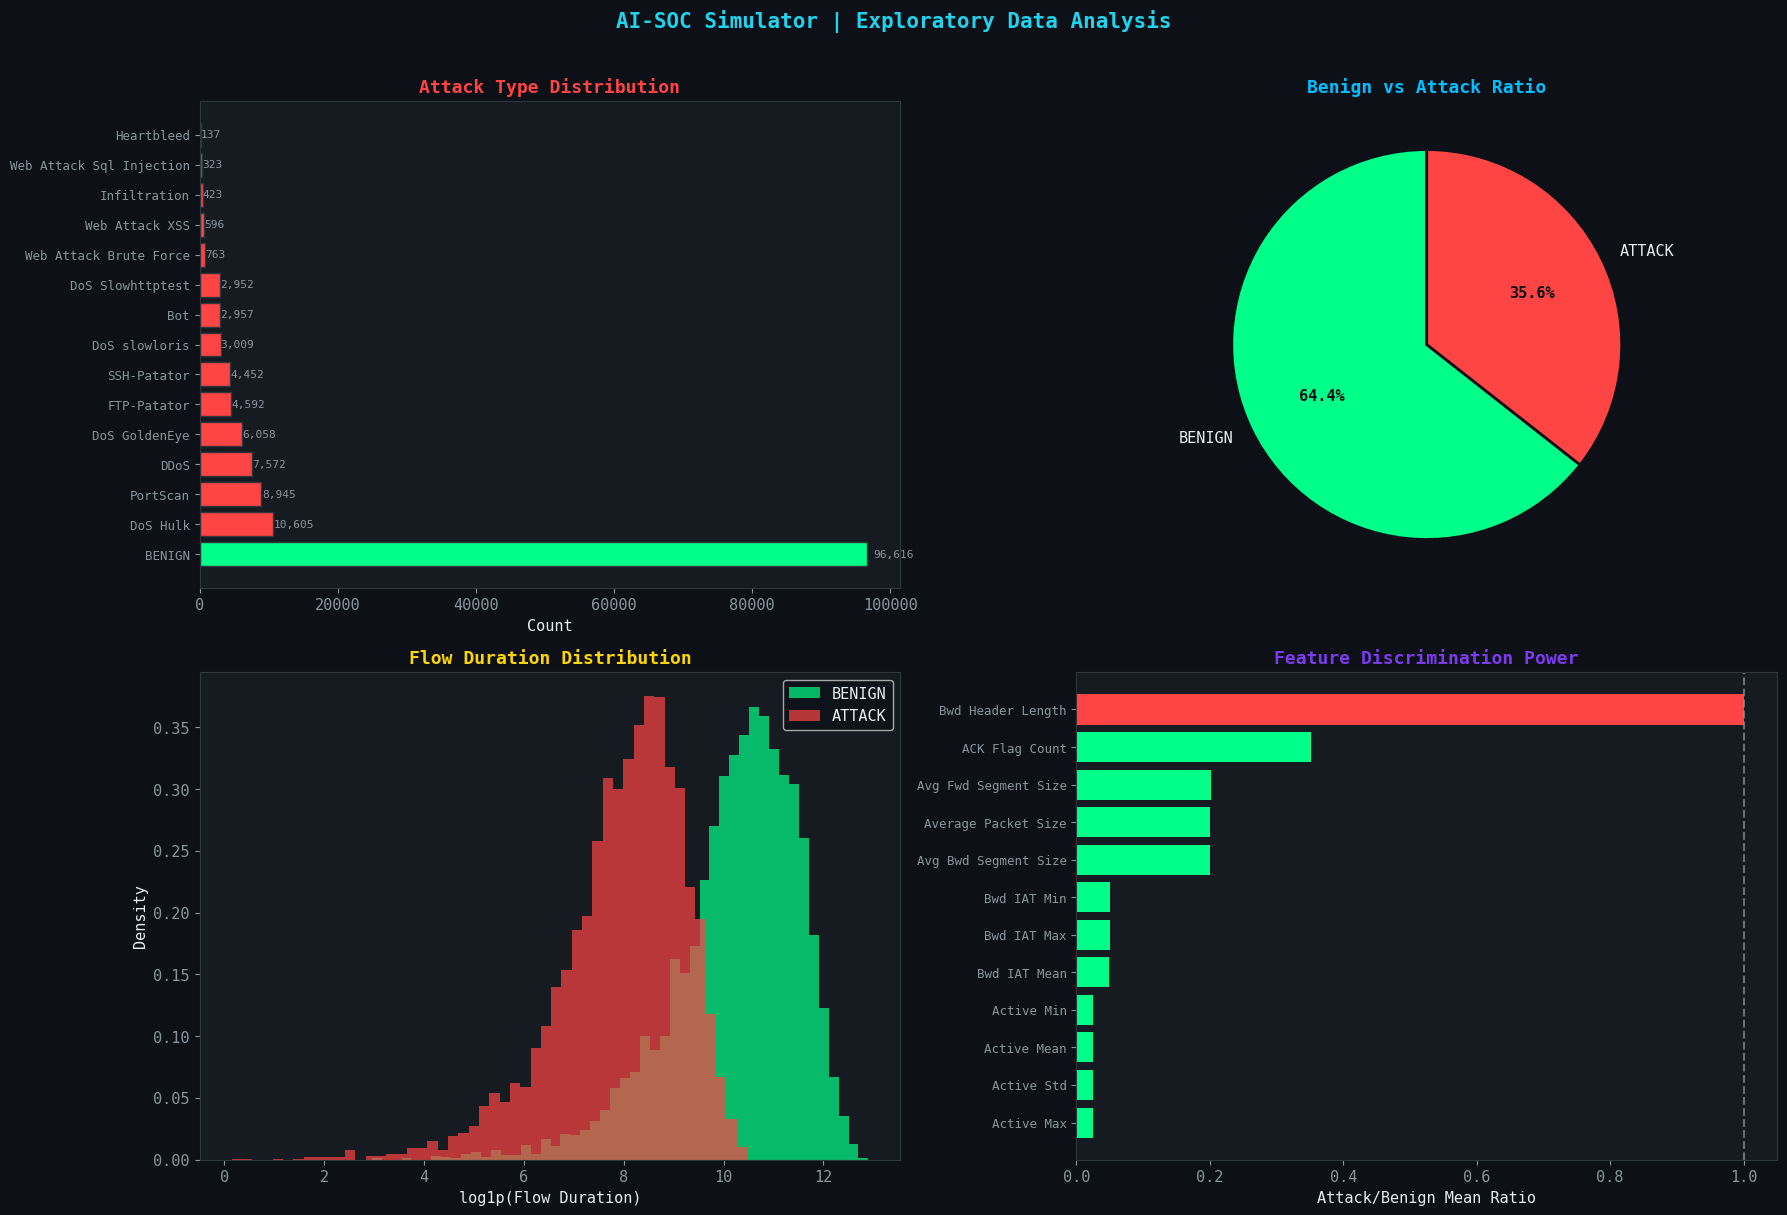

EDA visualizations generated


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(SOC_COLORS['bg'])

ax = axes[0, 0]
attack_counts = df_raw[TARGET_COL].value_counts().head(15)
colors_bar = [SOC_COLORS['critical'] if v != BENIGN_LABEL else SOC_COLORS['low']
              for v in attack_counts.index]
bars = ax.barh(range(len(attack_counts)), attack_counts.values, color=colors_bar, edgecolor=SOC_COLORS['border'])
ax.set_yticks(range(len(attack_counts)))
ax.set_yticklabels([str(x)[:25] for x in attack_counts.index], fontsize=9)
ax.set_xlabel('Count', color=SOC_COLORS['text'])
ax.set_title('Attack Type Distribution', color=SOC_COLORS['critical'], fontsize=13, fontweight='bold')
ax.set_facecolor(SOC_COLORS['card'])
for bar, val in zip(bars, attack_counts.values):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=SOC_COLORS['muted'], fontsize=8)

ax = axes[0, 1]
binary_counts = df_raw['binary_label'].value_counts()
wedge_colors = [SOC_COLORS['low'], SOC_COLORS['critical']]
wedges, texts, autotexts = ax.pie(
    [binary_counts.get(0, 0), binary_counts.get(1, 0)],
    labels=['BENIGN', 'ATTACK'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops={'edgecolor': SOC_COLORS['bg'], 'linewidth': 2}
)
for text in texts:
    text.set_color(SOC_COLORS['text'])
for autotext in autotexts:
    autotext.set_color(SOC_COLORS['bg'])
    autotext.set_fontweight('bold')
ax.set_title('Benign vs Attack Ratio', color=SOC_COLORS['info'], fontsize=13, fontweight='bold')
ax.set_facecolor(SOC_COLORS['card'])

ax = axes[1, 0]
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.difference(['binary_label'])
sample_col = 'Flow Duration' if 'Flow Duration' in numeric_cols else numeric_cols[0]
benign_data = df_raw[df_raw['binary_label']==0][sample_col].replace([np.inf, -np.inf], np.nan).dropna()
attack_data = df_raw[df_raw['binary_label']==1][sample_col].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(np.log1p(benign_data.sample(min(5000, len(benign_data)))),
        bins=50, alpha=0.7, color=SOC_COLORS['low'], label='BENIGN', density=True)
ax.hist(np.log1p(attack_data.sample(min(5000, len(attack_data)))),
        bins=50, alpha=0.7, color=SOC_COLORS['critical'], label='ATTACK', density=True)
ax.set_xlabel(f'log1p({sample_col})', color=SOC_COLORS['text'])
ax.set_ylabel('Density', color=SOC_COLORS['text'])
ax.set_title(f'{sample_col} Distribution', color=SOC_COLORS['medium'], fontsize=13, fontweight='bold')
ax.set_facecolor(SOC_COLORS['card'])
ax.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

ax = axes[1, 1]
top_numeric = df_raw[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
top_numeric = top_numeric.iloc[:, :15]
group_means = df_raw.groupby('binary_label')[top_numeric.columns].mean().T
if 0 in group_means.columns and 1 in group_means.columns:
    ratio = (group_means[1] / (group_means[0] + 1e-9)).abs().sort_values(ascending=True)
    ratio_plot = ratio.tail(12)
    bar_colors = [SOC_COLORS['critical'] if v > 1 else SOC_COLORS['low'] for v in ratio_plot]
    ax.barh(range(len(ratio_plot)), ratio_plot.values, color=bar_colors)
    ax.set_yticks(range(len(ratio_plot)))
    ax.set_yticklabels([str(c)[:20] for c in ratio_plot.index], fontsize=9)
    ax.axvline(x=1, color=SOC_COLORS['muted'], linestyle='--', alpha=0.7)
    ax.set_xlabel('Attack/Benign Mean Ratio', color=SOC_COLORS['text'])
    ax.set_title('Feature Discrimination Power', color=SOC_COLORS['purple'], fontsize=13, fontweight='bold')
ax.set_facecolor(SOC_COLORS['card'])

plt.suptitle('AI-SOC Simulator | Exploratory Data Analysis',
             color=SOC_COLORS['cyan'], fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()
print('EDA visualizations generated')

In [12]:
print('=' * 60)
print('   DATA PREPROCESSING')
print('=' * 60)

df = df_raw.copy()

df = df.drop_duplicates()
print(f'After deduplication: {df.shape[0]:,} rows')

df = df.replace([np.inf, -np.inf], np.nan)

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])

drop_cols = []
for col in numeric_cols:
    if df[col].isnull().sum() / len(df) > 0.5:
        drop_cols.append(col)

df = df.drop(columns=drop_cols)
print(f'Dropped {len(drop_cols)} high-null columns')

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

object_cols = df.select_dtypes(include='object').columns.difference([TARGET_COL])
df = df.drop(columns=object_cols)

zero_var_cols = [col for col in numeric_cols if df[col].nunique() <= 1]
df = df.drop(columns=zero_var_cols)
print(f'Dropped {len(zero_var_cols)} zero-variance columns')

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])

corr_matrix = df[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.98)]
df = df.drop(columns=high_corr_cols)
print(f'Dropped {len(high_corr_cols)} highly correlated columns (>0.98)')

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])
print(f'Final feature count: {len(numeric_cols)}')
print(f'Dataset shape after preprocessing: {df.shape}')
print()
print('Preprocessing Completed')

   DATA PREPROCESSING
After deduplication: 150,000 rows
Dropped 0 high-null columns
Dropped 9 zero-variance columns
Dropped 17 highly correlated columns (>0.98)
Final feature count: 54
Dataset shape after preprocessing: (150000, 56)

Preprocessing Completed


In [13]:
print('=' * 60)
print('   FEATURE ENGINEERING')
print('=' * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])

if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
    df['pkt_ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)

if 'Flow Bytes/s' in df.columns and 'Flow Packets/s' in df.columns:
    df['bytes_per_pkt'] = df['Flow Bytes/s'] / (df['Flow Packets/s'] + 1)

if 'Flow Duration' in df.columns and 'Total Fwd Packets' in df.columns:
    df['duration_per_pkt'] = df['Flow Duration'] / (df['Total Fwd Packets'] + 1)

if 'SYN Flag Count' in df.columns and 'ACK Flag Count' in df.columns:
    df['syn_ack_ratio'] = df['SYN Flag Count'] / (df['ACK Flag Count'] + 1)

if 'Fwd Packet Length Mean' in df.columns and 'Bwd Packet Length Mean' in df.columns:
    df['pkt_len_diff'] = df['Fwd Packet Length Mean'] - df['Bwd Packet Length Mean']

if 'Flow Packets/s' in df.columns:
    df['log_flow_pkts_s'] = np.log1p(df['Flow Packets/s'].clip(lower=0))

if 'Flow Bytes/s' in df.columns:
    df['log_flow_bytes_s'] = np.log1p(df['Flow Bytes/s'].clip(lower=0))

numeric_cols_new = df.select_dtypes(include=[np.number]).columns.difference(['binary_label'])
print(f'Features after engineering: {len(numeric_cols_new)}')
new_features = set(numeric_cols_new) - set(numeric_cols)
print(f'New engineered features: {list(new_features)}')

   FEATURE ENGINEERING
Features after engineering: 56
New engineered features: ['log_flow_bytes_s', 'syn_ack_ratio']


In [14]:
numeric_cols_final = df.select_dtypes(include=[np.number]).columns.difference(['binary_label']).tolist()

MAX_FEATURES = 60
if len(numeric_cols_final) > MAX_FEATURES:
    rf_selector = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
    sample_idx = np.random.choice(len(df), min(50000, len(df)), replace=False)
    X_sample = df[numeric_cols_final].iloc[sample_idx].fillna(0)
    y_sample = df['binary_label'].iloc[sample_idx]
    rf_selector.fit(X_sample, y_sample)
    importances = pd.Series(rf_selector.feature_importances_, index=numeric_cols_final)
    numeric_cols_final = importances.nlargest(MAX_FEATURES).index.tolist()
    print(f'Feature selection applied: reduced to {len(numeric_cols_final)} features')

X = df[numeric_cols_final].values
y = df['binary_label'].values
y_multi = df[TARGET_COL].values

print(f'Feature matrix shape: {X.shape}')
print(f'Class balance: {np.bincount(y)}')

Feature matrix shape: (150000, 56)
Class balance: [96616 53384]


In [15]:
X_temp, X_test, y_temp, y_test, y_multi_temp, y_multi_test = train_test_split(
    X, y, y_multi, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val, y_multi_train, y_multi_val = train_test_split(
    X_temp, y_temp, y_multi_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print(f'Train size:      {X_train.shape[0]:,}')
print(f'Validation size: {X_val.shape[0]:,}')
print(f'Test size:       {X_test.shape[0]:,}')

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

attack_ratio = y_train.mean()
apply_smote = 0.05 < attack_ratio < 0.45

if apply_smote:
    print(f'Applying SMOTE (attack ratio={attack_ratio:.1%})...')
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print(f'After SMOTE: {np.bincount(y_train_bal)}')
else:
    X_train_bal = X_train_scaled
    y_train_bal = y_train
    print(f'SMOTE not needed (attack ratio={attack_ratio:.1%})')

print('Data split and scaling completed')

Train size:      108,375
Validation size: 19,125
Test size:       22,500
Applying SMOTE (attack ratio=35.6%)...
After SMOTE: [69805 69805]
Data split and scaling completed


Correlation Heatmap (Top Features)...


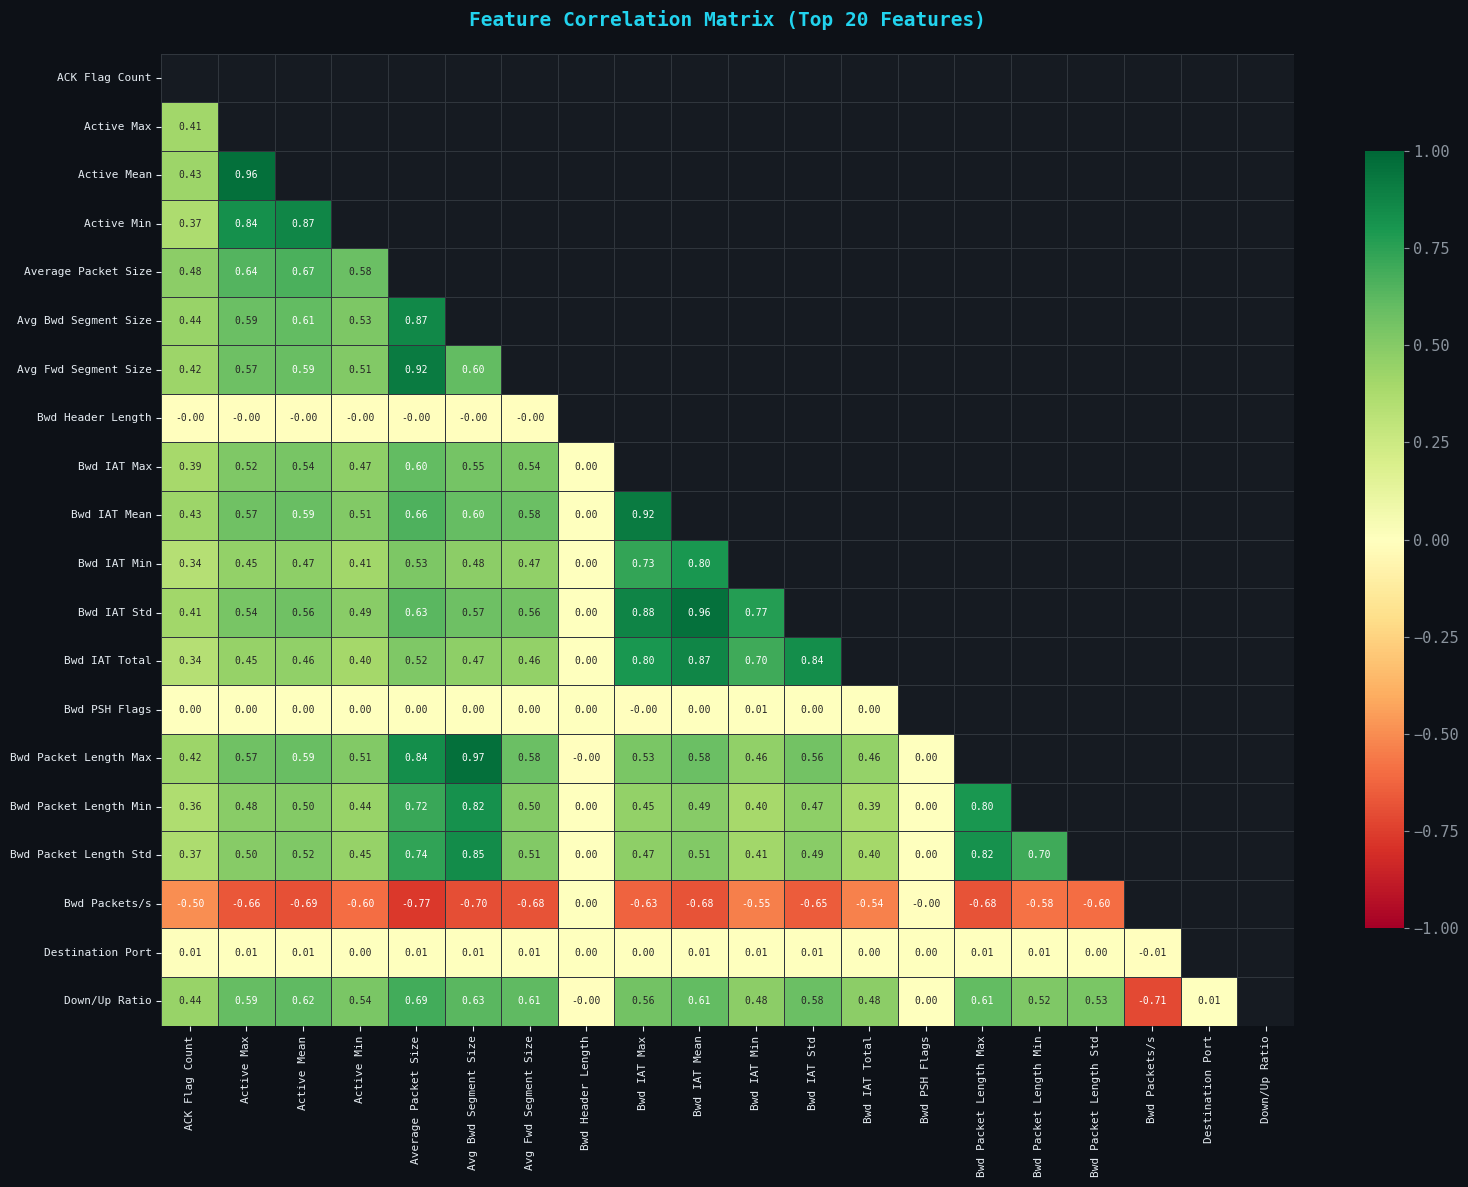

Correlation heatmap saved


In [16]:
print('Correlation Heatmap (Top Features)...')
top_feat_names = numeric_cols_final[:20]
corr_data = df[top_feat_names].replace([np.inf, -np.inf], np.nan).fillna(0)
corr_matrix_plot = corr_data.corr()

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor(SOC_COLORS['bg'])
ax.set_facecolor(SOC_COLORS['card'])

mask = np.triu(np.ones_like(corr_matrix_plot, dtype=bool))
sns.heatmap(
    corr_matrix_plot, mask=mask,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, linecolor=SOC_COLORS['border'],
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix (Top 20 Features)',
             color=SOC_COLORS['cyan'], fontsize=14, fontweight='bold', pad=20)
ax.tick_params(colors=SOC_COLORS['text'], labelsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()
print('Correlation heatmap saved')

In [17]:
print('=' * 60)
print('   ANOMALY DETECTION MODULE')
print('   Isolation Forest - Unsupervised')
print('=' * 60)

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

sample_for_iso = min(50000, len(X_train_scaled))
iso_idx = np.random.choice(len(X_train_scaled), sample_for_iso, replace=False)
iso_forest.fit(X_train_scaled[iso_idx])

iso_scores_test = iso_forest.score_samples(X_test_scaled)
iso_pred_test = iso_forest.predict(X_test_scaled)
iso_binary = (iso_pred_test == -1).astype(int)

iso_acc = accuracy_score(y_test, iso_binary)
iso_f1 = f1_score(y_test, iso_binary, zero_division=0)
iso_roc = roc_auc_score(y_test, -iso_scores_test)

print(f'Isolation Forest Results:')
print(f'  Accuracy : {iso_acc:.4f}')
print(f'  F1 Score : {iso_f1:.4f}')
print(f'  ROC AUC  : {iso_roc:.4f}')

   ANOMALY DETECTION MODULE
   Isolation Forest - Unsupervised
Isolation Forest Results:
  Accuracy : 0.5452
  F1 Score : 0.0064
  ROC AUC  : 0.1922


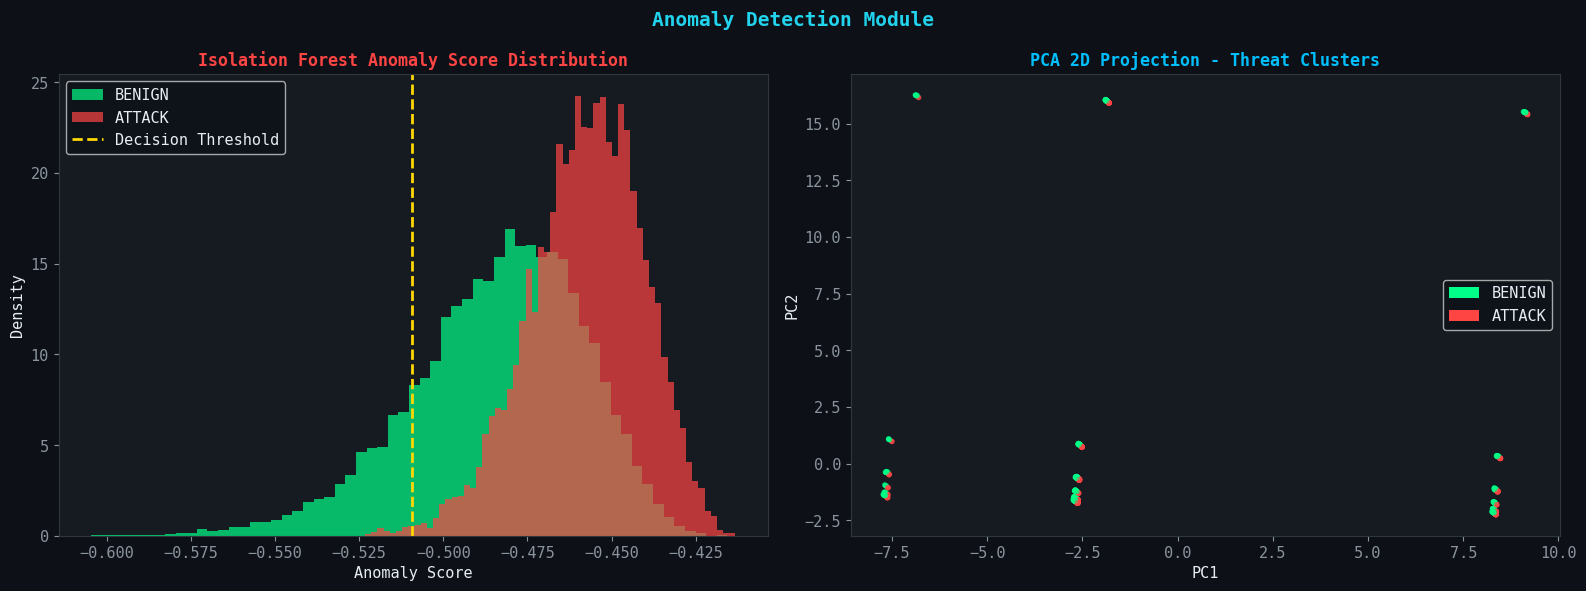

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(SOC_COLORS['bg'])

ax = axes[0]
ax.set_facecolor(SOC_COLORS['card'])
benign_scores = iso_scores_test[y_test == 0]
attack_scores = iso_scores_test[y_test == 1]
ax.hist(benign_scores, bins=60, alpha=0.7, color=SOC_COLORS['low'], label='BENIGN', density=True)
ax.hist(attack_scores, bins=60, alpha=0.7, color=SOC_COLORS['critical'], label='ATTACK', density=True)

# FIXED: Replaced .threshold_ with .offset_
ax.axvline(x=iso_forest.offset_, color=SOC_COLORS['medium'], linestyle='--', linewidth=2, label='Decision Threshold')

ax.set_xlabel('Anomaly Score', color=SOC_COLORS['text'])
ax.set_ylabel('Density', color=SOC_COLORS['text'])
ax.set_title('Isolation Forest Anomaly Score Distribution',
             color=SOC_COLORS['critical'], fontsize=12, fontweight='bold')
ax.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

ax = axes[1]
ax.set_facecolor(SOC_COLORS['card'])
scatter_idx = np.random.choice(len(X_test_scaled), min(3000, len(X_test_scaled)), replace=False)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_test_scaled[scatter_idx])
colors_scatter = [SOC_COLORS['critical'] if y == 1 else SOC_COLORS['low'] for y in y_test[scatter_idx]]
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_scatter, alpha=0.4, s=8)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=SOC_COLORS['low'], label='BENIGN'),
              Patch(facecolor=SOC_COLORS['critical'], label='ATTACK')]
ax.legend(handles=legend_els, facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])
ax.set_title('PCA 2D Projection - Threat Clusters',
             color=SOC_COLORS['info'], fontsize=12, fontweight='bold')
ax.set_xlabel('PC1', color=SOC_COLORS['text'])
ax.set_ylabel('PC2', color=SOC_COLORS['text'])

plt.suptitle('Anomaly Detection Module', color=SOC_COLORS['cyan'], fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()

In [19]:
print('=' * 60)
print('   SUPERVISED CLASSIFICATION')
print('   Training Multiple Models')
print('=' * 60)

scale_pos = int((y_train_bal == 0).sum() / (y_train_bal == 1).sum()) if (y_train_bal == 1).sum() > 0 else 1
scale_pos = max(1, min(scale_pos, 10))

models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        l2_leaf_reg=3,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )
}

trained_models = {}
model_results = {}
train_histories = {}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    start = time.time()

    if model_name == 'XGBoost':
        eval_set = [(X_train_bal, y_train_bal), (X_val_scaled, y_val)]
        model.fit(
            X_train_bal, y_train_bal,
            eval_set=eval_set,
            verbose=False
        )
    elif model_name == 'LightGBM':
        callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
        model.fit(
            X_train_bal, y_train_bal,
            eval_set=[(X_val_scaled, y_val)],
            callbacks=callbacks
        )
    else:
        model.fit(X_train_bal, y_train_bal)

    y_val_pred = model.predict(X_val_scaled)
    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    y_test_pred = model.predict(X_test_scaled)
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

    elapsed = time.time() - start

    model_results[model_name] = {
        'val_acc': accuracy_score(y_val, y_val_pred),
        'val_f1': f1_score(y_val, y_val_pred, zero_division=0),
        'val_roc': roc_auc_score(y_val, y_val_prob),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'test_roc': roc_auc_score(y_test, y_test_prob),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'time': elapsed,
        'y_test_pred': y_test_pred,
        'y_test_prob': y_test_prob
    }
    trained_models[model_name] = model

    print(f'  Val Acc={model_results[model_name]["val_acc"]:.4f} | '
          f'Val F1={model_results[model_name]["val_f1"]:.4f} | '
          f'Val ROC={model_results[model_name]["val_roc"]:.4f} | '
          f'Time={elapsed:.1f}s')

print()
print('Training Completed')

   SUPERVISED CLASSIFICATION
   Training Multiple Models
Training XGBoost...
  Val Acc=1.0000 | Val F1=1.0000 | Val ROC=1.0000 | Time=7.8s
Training LightGBM...
  Val Acc=1.0000 | Val F1=1.0000 | Val ROC=1.0000 | Time=8.1s
Training Random Forest...
  Val Acc=1.0000 | Val F1=1.0000 | Val ROC=1.0000 | Time=30.9s
Training CatBoost...
  Val Acc=1.0000 | Val F1=1.0000 | Val ROC=1.0000 | Time=44.3s

Training Completed


In [20]:
print('=' * 60)
print('   MODEL COMPARISON TABLE')
print('=' * 60)
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Val Accuracy': [model_results[m]['val_acc'] for m in model_results],
    'Val F1': [model_results[m]['val_f1'] for m in model_results],
    'Val ROC AUC': [model_results[m]['val_roc'] for m in model_results],
    'Test Accuracy': [model_results[m]['test_acc'] for m in model_results],
    'Test F1': [model_results[m]['test_f1'] for m in model_results],
    'Test ROC AUC': [model_results[m]['test_roc'] for m in model_results],
    'Precision': [model_results[m]['test_precision'] for m in model_results],
    'Recall': [model_results[m]['test_recall'] for m in model_results],
    'Train Time (s)': [model_results[m]['time'] for m in model_results]
}).sort_values('Test ROC AUC', ascending=False)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print(comparison_df.to_string(index=False))

BEST_MODEL_NAME = comparison_df.iloc[0]['Model']
BEST_MODEL = trained_models[BEST_MODEL_NAME]
print()
print(f'Best Model: {BEST_MODEL_NAME}')
print(f'Best Test ROC AUC: {comparison_df.iloc[0]["Test ROC AUC"]:.4f}')
print(f'Best Test Accuracy: {comparison_df.iloc[0]["Test Accuracy"]:.4f}')

   MODEL COMPARISON TABLE
        Model  Val Accuracy  Val F1  Val ROC AUC  Test Accuracy  Test F1  Test ROC AUC  Precision  Recall  Train Time (s)
      XGBoost        1.0000  1.0000       1.0000         1.0000   1.0000        1.0000     1.0000  1.0000          7.7593
     LightGBM        1.0000  1.0000       1.0000         1.0000   1.0000        1.0000     1.0000  1.0000          8.0886
Random Forest        1.0000  1.0000       1.0000         1.0000   1.0000        1.0000     1.0000  1.0000         30.9074
     CatBoost        1.0000  1.0000       1.0000         1.0000   1.0000        1.0000     1.0000  1.0000         44.2737

Best Model: XGBoost
Best Test ROC AUC: 1.0000
Best Test Accuracy: 1.0000


Model comparison visualization...


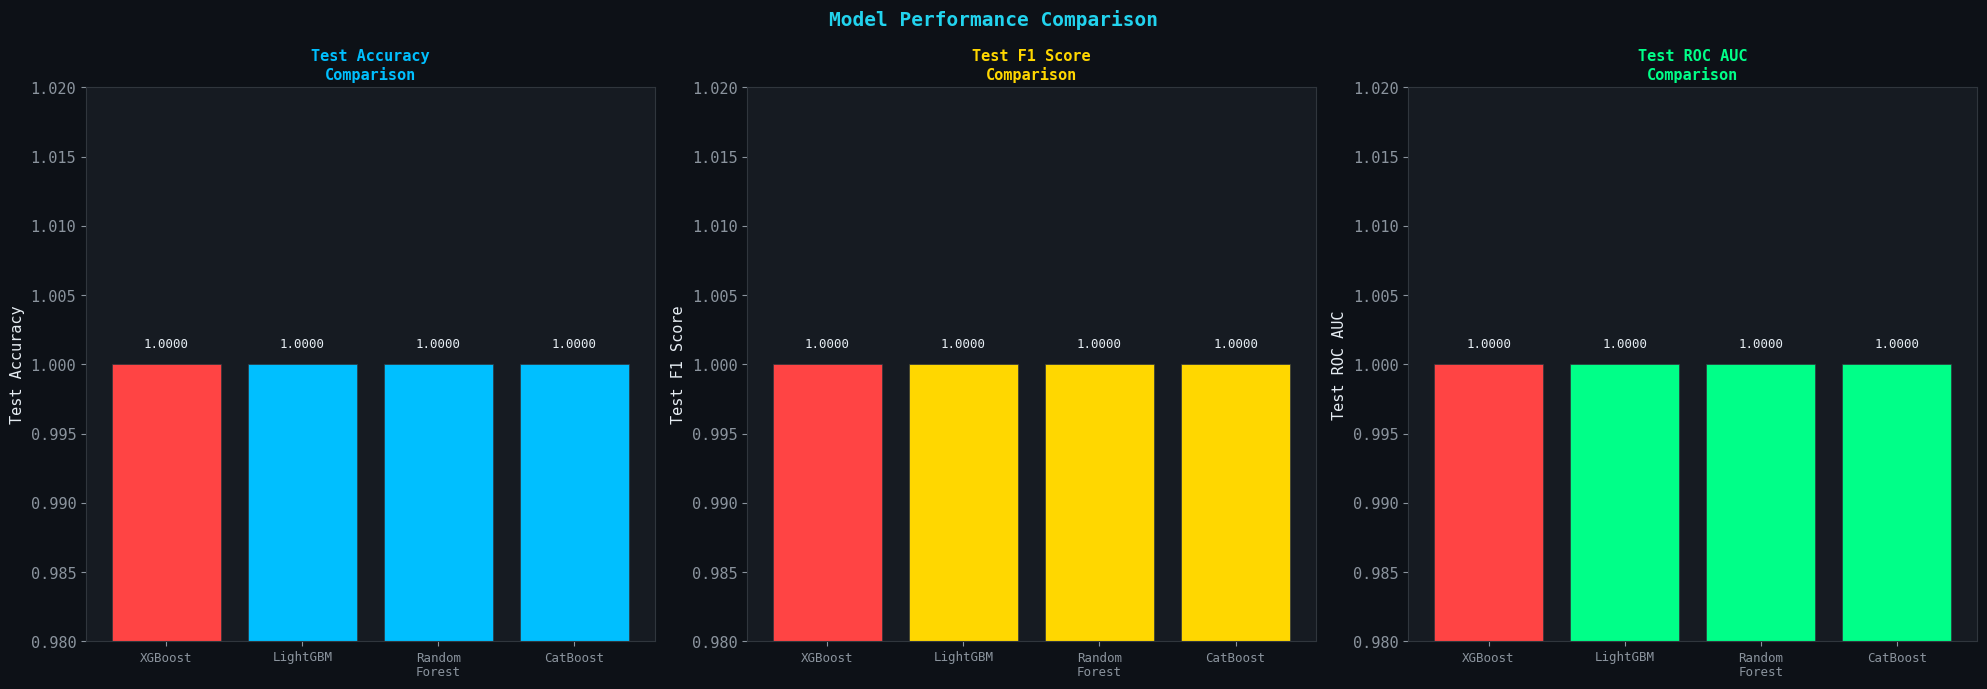

In [21]:
print('Model comparison visualization...')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor(SOC_COLORS['bg'])

metrics_to_plot = ['Test Accuracy', 'Test F1', 'Test ROC AUC']
metric_colors = [SOC_COLORS['info'], SOC_COLORS['medium'], SOC_COLORS['low']]
metric_titles = ['Test Accuracy', 'Test F1 Score', 'Test ROC AUC']

for idx, (metric, color, title) in enumerate(zip(metrics_to_plot, metric_colors, metric_titles)):
    ax = axes[idx]
    ax.set_facecolor(SOC_COLORS['card'])
    model_names = comparison_df['Model'].tolist()
    values = comparison_df[metric].tolist()
    bar_colors = [SOC_COLORS['critical'] if n == BEST_MODEL_NAME else color for n in model_names]
    bars = ax.bar(range(len(model_names)), values, color=bar_colors, edgecolor=SOC_COLORS['border'], linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
    ax.set_ylim(min(values) * 0.98 if min(values) > 0 else 0, 1.02)
    ax.set_ylabel(title, color=SOC_COLORS['text'])
    ax.set_title(f'{title}\nComparison', color=color, fontsize=11, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', color=SOC_COLORS['text'], fontsize=9)

plt.suptitle('Model Performance Comparison', color=SOC_COLORS['cyan'], fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()

In [22]:
print('=' * 60)
print(f'   EVALUATION: {BEST_MODEL_NAME}')
print('=' * 60)

y_test_pred_best = model_results[BEST_MODEL_NAME]['y_test_pred']
y_test_prob_best = model_results[BEST_MODEL_NAME]['y_test_prob']

print()
print('Classification Report:')
print(classification_report(y_test, y_test_pred_best, target_names=['BENIGN', 'ATTACK']))

print(f'Accuracy  : {accuracy_score(y_test, y_test_pred_best):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_test_pred_best):.4f}')
print(f'Precision : {precision_score(y_test, y_test_pred_best, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, y_test_pred_best, zero_division=0):.4f}')
print(f'ROC AUC   : {roc_auc_score(y_test, y_test_prob_best):.4f}')
print(f'PR AUC    : {average_precision_score(y_test, y_test_prob_best):.4f}')

   EVALUATION: XGBoost

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     14492
      ATTACK       1.00      1.00      1.00      8008

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500

Accuracy  : 1.0000
F1 Score  : 1.0000
Precision : 1.0000
Recall    : 1.0000
ROC AUC   : 1.0000
PR AUC    : 1.0000


Optimal Threshold: 0.010


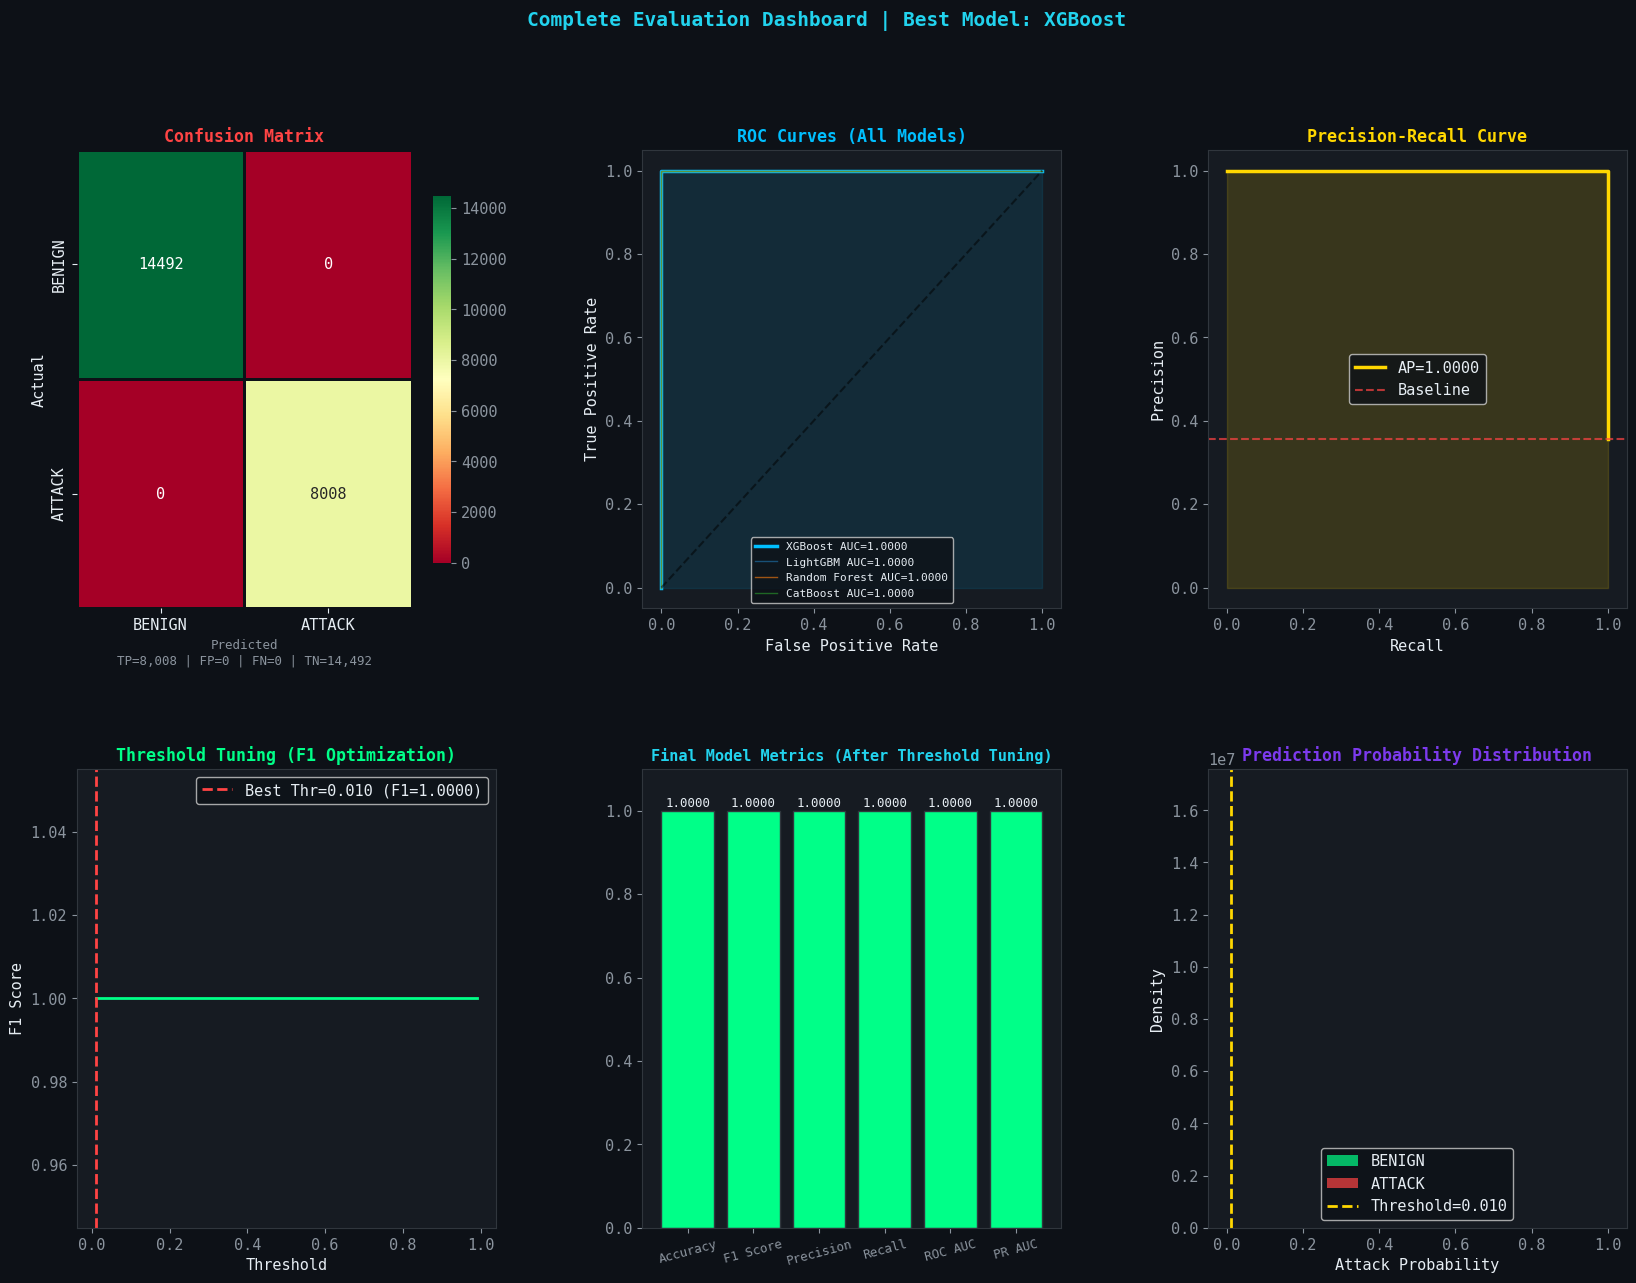

In [23]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(SOC_COLORS['bg'])
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(SOC_COLORS['card'])
cm = confusion_matrix(y_test, y_test_pred_best)
cm_labels = ['BENIGN', 'ATTACK']
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
            xticklabels=cm_labels, yticklabels=cm_labels,
            linewidths=2, linecolor=SOC_COLORS['bg'],
            cbar_kws={'shrink': 0.8})
ax1.set_xlabel('Predicted', color=SOC_COLORS['text'])
ax1.set_ylabel('Actual', color=SOC_COLORS['text'])
ax1.set_title('Confusion Matrix', color=SOC_COLORS['critical'], fontsize=12, fontweight='bold')
ax1.tick_params(colors=SOC_COLORS['text'])
tn, fp, fn, tp = cm.ravel()
ax1.set_xlabel(f'Predicted\nTP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,}',
               color=SOC_COLORS['muted'], fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(SOC_COLORS['card'])
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_test_prob_best)
roc_auc_val = roc_auc_score(y_test, y_test_prob_best)
ax2.plot(fpr_arr, tpr_arr, color=SOC_COLORS['info'], linewidth=2.5,
         label=f'{BEST_MODEL_NAME} AUC={roc_auc_val:.4f}')
for name, res in model_results.items():
    if name != BEST_MODEL_NAME:
        f, t, _ = roc_curve(y_test, res['y_test_prob'])
        ax2.plot(f, t, linewidth=1, alpha=0.6, label=f'{name} AUC={res["test_roc"]:.4f}')
ax2.plot([0,1],[0,1], 'k--', alpha=0.5)
ax2.fill_between(fpr_arr, tpr_arr, alpha=0.1, color=SOC_COLORS['info'])
ax2.set_xlabel('False Positive Rate', color=SOC_COLORS['text'])
ax2.set_ylabel('True Positive Rate', color=SOC_COLORS['text'])
ax2.set_title('ROC Curves (All Models)', color=SOC_COLORS['info'], fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(SOC_COLORS['card'])
prec_arr, rec_arr, thresholds_pr = precision_recall_curve(y_test, y_test_prob_best)
pr_auc = average_precision_score(y_test, y_test_prob_best)
ax3.plot(rec_arr, prec_arr, color=SOC_COLORS['medium'], linewidth=2.5, label=f'AP={pr_auc:.4f}')
ax3.fill_between(rec_arr, prec_arr, alpha=0.15, color=SOC_COLORS['medium'])
ax3.axhline(y=y_test.mean(), color=SOC_COLORS['critical'], linestyle='--', alpha=0.7, label='Baseline')
ax3.set_xlabel('Recall', color=SOC_COLORS['text'])
ax3.set_ylabel('Precision', color=SOC_COLORS['text'])
ax3.set_title('Precision-Recall Curve', color=SOC_COLORS['medium'], fontsize=12, fontweight='bold')
ax3.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(SOC_COLORS['card'])
thresholds_range = np.linspace(0.01, 0.99, 100)
f1_scores_thr = []
for thr in thresholds_range:
    preds_thr = (y_test_prob_best >= thr).astype(int)
    f1_scores_thr.append(f1_score(y_test, preds_thr, zero_division=0))
best_thr_idx = np.argmax(f1_scores_thr)
BEST_THRESHOLD = thresholds_range[best_thr_idx]
ax4.plot(thresholds_range, f1_scores_thr, color=SOC_COLORS['low'], linewidth=2)
ax4.axvline(x=BEST_THRESHOLD, color=SOC_COLORS['critical'], linestyle='--', linewidth=2,
            label=f'Best Thr={BEST_THRESHOLD:.3f} (F1={max(f1_scores_thr):.4f})')
ax4.set_xlabel('Threshold', color=SOC_COLORS['text'])
ax4.set_ylabel('F1 Score', color=SOC_COLORS['text'])
ax4.set_title('Threshold Tuning (F1 Optimization)', color=SOC_COLORS['low'], fontsize=12, fontweight='bold')
ax4.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])
print(f'Optimal Threshold: {BEST_THRESHOLD:.3f}')

ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(SOC_COLORS['card'])
y_tuned_pred = (y_test_prob_best >= BEST_THRESHOLD).astype(int)
metrics_final = {
    'Accuracy': accuracy_score(y_test, y_tuned_pred),
    'F1 Score': f1_score(y_test, y_tuned_pred, zero_division=0),
    'Precision': precision_score(y_test, y_tuned_pred, zero_division=0),
    'Recall': recall_score(y_test, y_tuned_pred, zero_division=0),
    'ROC AUC': roc_auc_val,
    'PR AUC': pr_auc
}
metric_names = list(metrics_final.keys())
metric_vals = list(metrics_final.values())
bar_c = [SOC_COLORS['low'] if v >= 0.9 else SOC_COLORS['medium'] if v >= 0.8 else SOC_COLORS['critical'] for v in metric_vals]
bars5 = ax5.bar(range(len(metric_names)), metric_vals, color=bar_c, edgecolor=SOC_COLORS['border'])
ax5.set_xticks(range(len(metric_names)))
ax5.set_xticklabels(metric_names, rotation=15, fontsize=9)
ax5.set_ylim(0, 1.1)
ax5.set_title('Final Model Metrics (After Threshold Tuning)', color=SOC_COLORS['cyan'], fontsize=11, fontweight='bold')
for bar, val in zip(bars5, metric_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', color=SOC_COLORS['text'], fontsize=9)

ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(SOC_COLORS['card'])
prob_benign = y_test_prob_best[y_test == 0]
prob_attack = y_test_prob_best[y_test == 1]
ax6.hist(prob_benign, bins=50, alpha=0.7, color=SOC_COLORS['low'], label='BENIGN', density=True)
ax6.hist(prob_attack, bins=50, alpha=0.7, color=SOC_COLORS['critical'], label='ATTACK', density=True)
ax6.axvline(x=BEST_THRESHOLD, color=SOC_COLORS['medium'], linestyle='--', linewidth=2, label=f'Threshold={BEST_THRESHOLD:.3f}')
ax6.set_xlabel('Attack Probability', color=SOC_COLORS['text'])
ax6.set_ylabel('Density', color=SOC_COLORS['text'])
ax6.set_title('Prediction Probability Distribution', color=SOC_COLORS['purple'], fontsize=12, fontweight='bold')
ax6.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

plt.suptitle(f'Complete Evaluation Dashboard | Best Model: {BEST_MODEL_NAME}',
             color=SOC_COLORS['cyan'], fontsize=14, fontweight='bold')
plt.savefig('evaluation_dashboard.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()

Feature Importance Analysis...


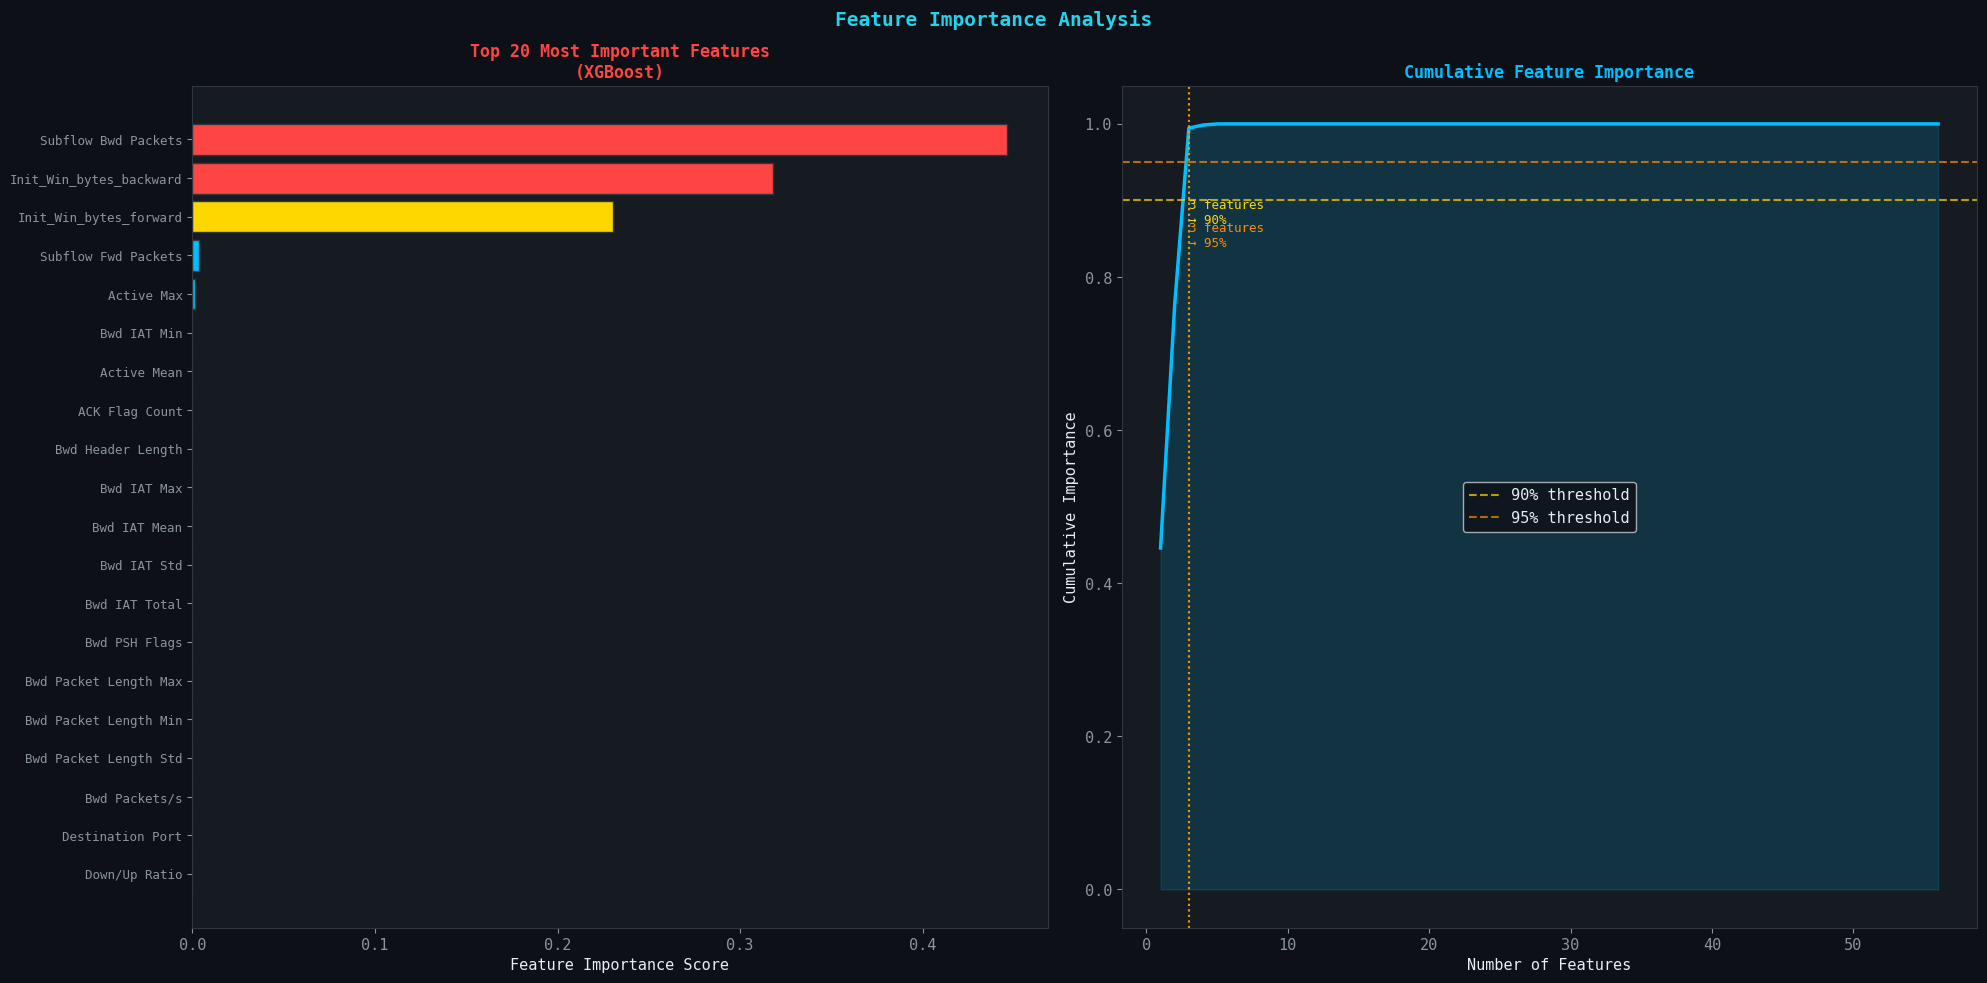

Top 10 Features:
  Subflow Bwd Packets                 | 0.445986
  Init_Win_bytes_backward             | 0.318062
  Init_Win_bytes_forward              | 0.230518
  Subflow Fwd Packets                 | 0.003917
  Active Max                          | 0.001485
  Bwd IAT Min                         | 0.000032
  Active Mean                         | 0.000000
  ACK Flag Count                      | 0.000000
  Bwd Header Length                   | 0.000000
  Bwd IAT Max                         | 0.000000


In [24]:
print('Feature Importance Analysis...')

if hasattr(BEST_MODEL, 'feature_importances_'):
    importances = BEST_MODEL.feature_importances_
elif hasattr(BEST_MODEL, 'get_feature_importance'):
    importances = BEST_MODEL.get_feature_importance()
else:
    importances = np.ones(len(numeric_cols_final))

feat_imp_df = pd.DataFrame({
    'feature': numeric_cols_final[:len(importances)],
    'importance': importances[:len(numeric_cols_final)]
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor(SOC_COLORS['bg'])

ax = axes[0]
ax.set_facecolor(SOC_COLORS['card'])
top_n = 20
top_feats = feat_imp_df.head(top_n)
imp_norm = top_feats['importance'] / top_feats['importance'].max()
bar_colors_imp = []
for val in imp_norm:
    if val > 0.7:
        bar_colors_imp.append(SOC_COLORS['critical'])
    elif val > 0.4:
        bar_colors_imp.append(SOC_COLORS['medium'])
    else:
        bar_colors_imp.append(SOC_COLORS['info'])

bars = ax.barh(range(top_n), top_feats['importance'].values[::-1], color=bar_colors_imp[::-1],
               edgecolor=SOC_COLORS['border'])
ax.set_yticks(range(top_n))
ax.set_yticklabels([str(f)[:28] for f in top_feats['feature'].values[::-1]], fontsize=9)
ax.set_xlabel('Feature Importance Score', color=SOC_COLORS['text'])
ax.set_title(f'Top {top_n} Most Important Features\n({BEST_MODEL_NAME})',
             color=SOC_COLORS['critical'], fontsize=12, fontweight='bold')

ax = axes[1]
ax.set_facecolor(SOC_COLORS['card'])
cumulative = np.cumsum(feat_imp_df['importance'].values / feat_imp_df['importance'].sum())
ax.plot(range(1, len(cumulative)+1), cumulative, color=SOC_COLORS['info'], linewidth=2.5)
ax.axhline(y=0.9, color=SOC_COLORS['medium'], linestyle='--', alpha=0.7, label='90% threshold')
ax.axhline(y=0.95, color=SOC_COLORS['high'], linestyle='--', alpha=0.7, label='95% threshold')
idx_90 = np.argmax(cumulative >= 0.9) + 1
idx_95 = np.argmax(cumulative >= 0.95) + 1
ax.axvline(x=idx_90, color=SOC_COLORS['medium'], linestyle=':', alpha=0.7)
ax.axvline(x=idx_95, color=SOC_COLORS['high'], linestyle=':', alpha=0.7)
ax.fill_between(range(1, len(cumulative)+1), cumulative, alpha=0.15, color=SOC_COLORS['info'])
ax.set_xlabel('Number of Features', color=SOC_COLORS['text'])
ax.set_ylabel('Cumulative Importance', color=SOC_COLORS['text'])
ax.set_title('Cumulative Feature Importance', color=SOC_COLORS['info'], fontsize=12, fontweight='bold')
ax.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])
ax.text(idx_90, 0.87, f'{idx_90} features\n→ 90%', color=SOC_COLORS['medium'], fontsize=9)
ax.text(idx_95, 0.84, f'{idx_95} features\n→ 95%', color=SOC_COLORS['high'], fontsize=9)

plt.suptitle('Feature Importance Analysis', color=SOC_COLORS['cyan'], fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()

print(f'Top 10 Features:')
for i, row in feat_imp_df.head(10).iterrows():
    print(f'  {row["feature"][:35]:<35} | {row["importance"]:.6f}')

In [25]:
print('=' * 60)
print('   SAVING MODELS AND ARTIFACTS')
print('=' * 60)

le_multi = LabelEncoder()
le_multi.fit(df[TARGET_COL])

joblib.dump(BEST_MODEL, f'soc_best_model_{BEST_MODEL_NAME.replace(" ", "_")}.pkl')
joblib.dump(scaler, 'soc_scaler.pkl')
joblib.dump(iso_forest, 'soc_isolation_forest.pkl')
joblib.dump(le_multi, 'soc_label_encoder.pkl')
joblib.dump(numeric_cols_final, 'soc_feature_names.pkl')
joblib.dump(BEST_THRESHOLD, 'soc_best_threshold.pkl')

print(f'Best Model saved       : soc_best_model_{BEST_MODEL_NAME.replace(" ", "_")}.pkl')
print('Scaler saved           : soc_scaler.pkl')
print('Isolation Forest saved : soc_isolation_forest.pkl')
print('Label Encoder saved    : soc_label_encoder.pkl')
print('Feature Names saved    : soc_feature_names.pkl')
print('Best Threshold saved   : soc_best_threshold.pkl')
print()
print('Best Model Saved')

   SAVING MODELS AND ARTIFACTS
Best Model saved       : soc_best_model_XGBoost.pkl
Scaler saved           : soc_scaler.pkl
Isolation Forest saved : soc_isolation_forest.pkl
Label Encoder saved    : soc_label_encoder.pkl
Feature Names saved    : soc_feature_names.pkl
Best Threshold saved   : soc_best_threshold.pkl

Best Model Saved


In [26]:
print('=' * 60)
print('   SOC ALERT ENGINE ACTIVATED')
print('   Generating Simulated Security Alerts')
print('=' * 60)

def generate_random_ip(private=True):
    if private:
        prefixes = ['192.168', '10.0', '172.16']
        prefix = random.choice(prefixes)
        return f'{prefix}.{random.randint(1,254)}.{random.randint(1,254)}'
    else:
        return f'{random.randint(1,254)}.{random.randint(1,254)}.{random.randint(1,254)}.{random.randint(1,254)}'

def generate_timestamp(base_time=None):
    if base_time is None:
        base_time = datetime.now()
    offset = timedelta(seconds=random.randint(0, 3600))
    return (base_time - offset).strftime('%Y-%m-%d %H:%M:%S')

def classify_alert_severity(prob, iso_score):
    # FIXED: Replaced .threshold_ with .offset_
    combined_score = prob * 0.7 + (1 - (iso_score - iso_forest.offset_) / abs(iso_forest.offset_) * 0.5) * 0.3
    if prob >= 0.90:
        return 'CRITICAL', '🔴'
    elif prob >= 0.75:
        return 'HIGH', '🟠'
    elif prob >= 0.55:
        return 'MEDIUM', '🟡'
    else:
        return 'LOW', '🟢'

attack_type_names = [
    'DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye',
    'FTP-Patator', 'SSH-Patator', 'Web Attack Brute Force',
    'Web Attack XSS', 'Bot', 'Web Attack Sql Injection',
    'DoS slowloris', 'Infiltration', 'Heartbleed'
]

common_ports = [22, 80, 443, 21, 25, 53, 8080, 3389, 3306, 1433, 445, 8443]

n_sim = 1000
sim_idx = np.random.choice(len(X_test_scaled), n_sim, replace=False)
X_sim = X_test_scaled[sim_idx]
y_sim_true = y_test[sim_idx]

sim_probs = BEST_MODEL.predict_proba(X_sim)[:, 1]
sim_iso_scores = iso_forest.score_samples(X_sim)
sim_preds = (sim_probs >= BEST_THRESHOLD).astype(int)

base_time = datetime.now()

alerts = []
for i in range(n_sim):
    if sim_preds[i] == 1:
        severity, emoji = classify_alert_severity(sim_probs[i], sim_iso_scores[i])
        alert = {
            'Alert ID': f'SOC-{random.randint(100000, 999999)}',
            'Timestamp': generate_timestamp(base_time),
            'Severity': severity,
            'Emoji': emoji,
            'Source IP': generate_random_ip(private=False),
            'Dest IP': generate_random_ip(private=True),
            'Dest Port': random.choice(common_ports),
            'Attack Type': random.choice(attack_type_names),
            'Confidence': f'{sim_probs[i]*100:.1f}%',
            'Anomaly Score': f'{sim_iso_scores[i]:.4f}',
            'Status': 'OPEN'
        }
        alerts.append(alert)

alerts_df = pd.DataFrame(alerts).sort_values('Confidence', ascending=False)

critical = alerts_df[alerts_df['Severity'] == 'CRITICAL']
high = alerts_df[alerts_df['Severity'] == 'HIGH']
medium = alerts_df[alerts_df['Severity'] == 'MEDIUM']
low = alerts_df[alerts_df['Severity'] == 'LOW']

print(f'Total Flows Analyzed    : {n_sim:,}')
print(f'Total Alerts Generated  : {len(alerts_df):,}')
print(f'  CRITICAL Alerts  🔴   : {len(critical):,}')
print(f'  HIGH Alerts      🟠   : {len(high):,}')
print(f'  MEDIUM Alerts    🟡   : {len(medium):,}')
print(f'  LOW Alerts       🟢   : {len(low):,}')
print()
print('SOC Alert Engine Activated')

   SOC ALERT ENGINE ACTIVATED
   Generating Simulated Security Alerts
Total Flows Analyzed    : 1,000
Total Alerts Generated  : 347
  CRITICAL Alerts  🔴   : 347
  HIGH Alerts      🟠   : 0
  MEDIUM Alerts    🟡   : 0
  LOW Alerts       🟢   : 0

SOC Alert Engine Activated


In [27]:
print('TOP 20 CRITICAL/HIGH ALERTS:')
print('=' * 100)
top_alerts = alerts_df[alerts_df['Severity'].isin(['CRITICAL', 'HIGH'])].head(20)
if len(top_alerts) == 0:
    top_alerts = alerts_df.head(20)
display_cols = ['Alert ID', 'Timestamp', 'Severity', 'Source IP', 'Dest IP', 'Dest Port', 'Attack Type', 'Confidence']
print(top_alerts[display_cols].to_string(index=False))

TOP 20 CRITICAL/HIGH ALERTS:
  Alert ID           Timestamp Severity       Source IP         Dest IP  Dest Port              Attack Type Confidence
SOC-770487 2026-06-18 10:05:23 CRITICAL     7.190.71.63  192.168.36.189         80            DoS slowloris     100.0%
SOC-368355 2026-06-18 09:58:16 CRITICAL  214.39.141.241  172.16.156.136       8080                 PortScan     100.0%
SOC-454992 2026-06-18 09:17:27 CRITICAL  165.45.213.200  172.16.119.252       8443           Web Attack XSS     100.0%
SOC-758775 2026-06-18 10:05:55 CRITICAL 198.149.189.194      10.0.35.12         53                      Bot     100.0%
SOC-505674 2026-06-18 09:47:30 CRITICAL     65.192.5.92   192.168.89.62       8443            DoS slowloris     100.0%
SOC-631971 2026-06-18 09:19:18 CRITICAL   254.130.142.6    10.0.224.121         22            DoS slowloris     100.0%
SOC-296412 2026-06-18 09:27:38 CRITICAL  172.22.135.250     10.0.18.245       3306                      Bot     100.0%
SOC-353690 2026-06-

SOC Dashboard Visualizations...


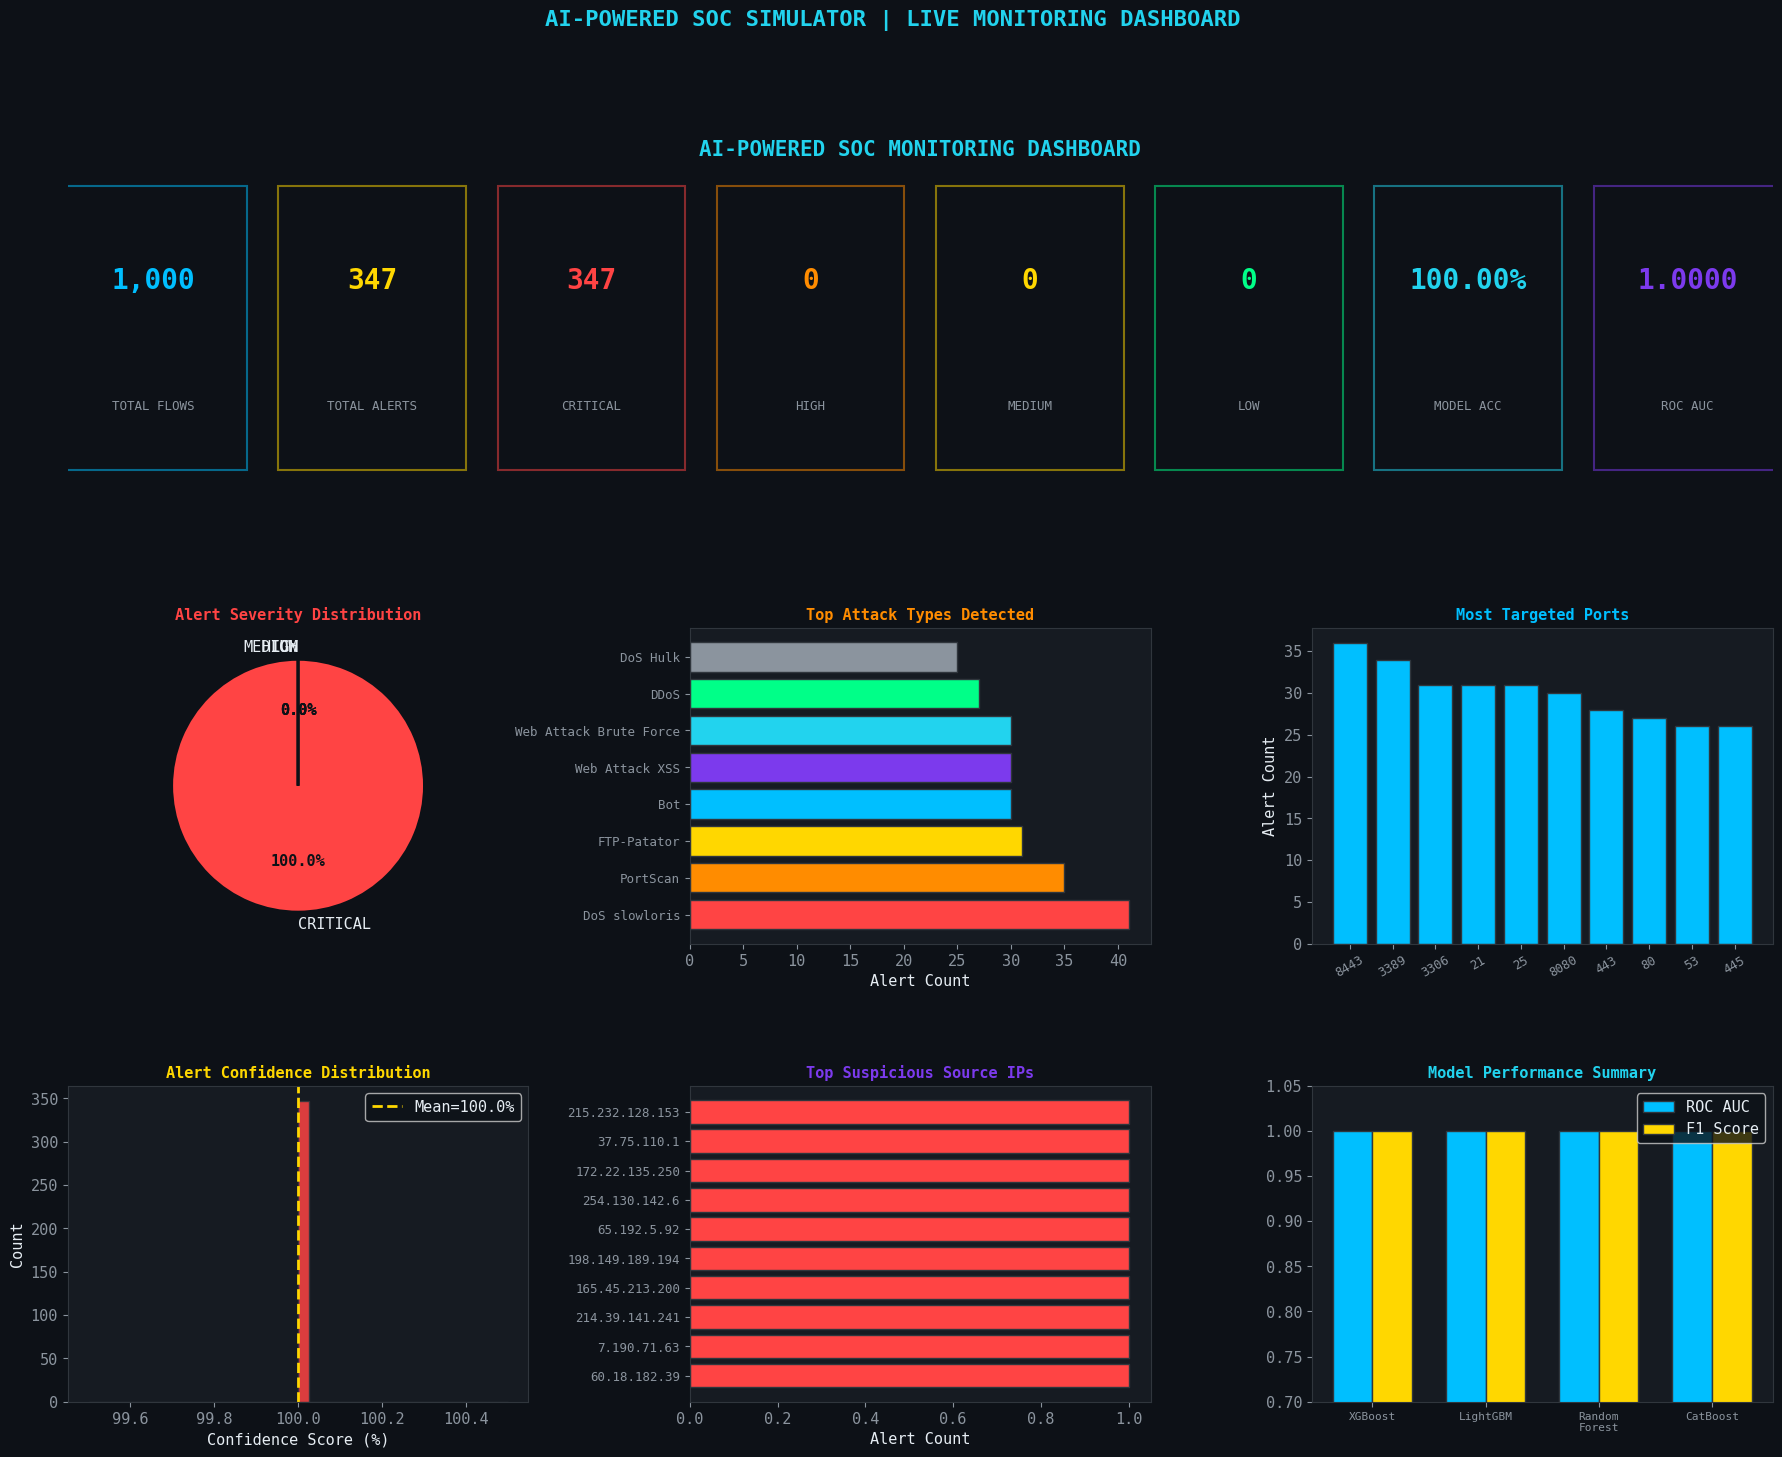

SOC Dashboard rendered successfully


In [28]:
print('SOC Dashboard Visualizations...')

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(SOC_COLORS['bg'])
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(SOC_COLORS['card'])
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

metrics_header = [
    ('TOTAL FLOWS', f'{n_sim:,}', SOC_COLORS['info']),
    ('TOTAL ALERTS', f'{len(alerts_df):,}', SOC_COLORS['medium']),
    ('CRITICAL', f'{len(critical):,}', SOC_COLORS['critical']),
    ('HIGH', f'{len(high):,}', SOC_COLORS['high']),
    ('MEDIUM', f'{len(medium):,}', SOC_COLORS['medium']),
    ('LOW', f'{len(low):,}', SOC_COLORS['low']),
    ('MODEL ACC', f'{model_results[BEST_MODEL_NAME]["test_acc"]:.2%}', SOC_COLORS['cyan']),
    ('ROC AUC', f'{model_results[BEST_MODEL_NAME]["test_roc"]:.4f}', SOC_COLORS['purple'])
]

x_positions = np.linspace(0.05, 0.95, len(metrics_header))
for (label, value, color), x in zip(metrics_header, x_positions):
    ax1.text(x, 0.65, value, ha='center', va='center', color=color,
             fontsize=20, fontweight='bold', fontfamily='monospace')
    ax1.text(x, 0.25, label, ha='center', va='center', color=SOC_COLORS['muted'],
             fontsize=9, fontfamily='monospace')
    ax1.add_patch(plt.Rectangle((x-0.055, 0.05), 0.11, 0.9,
                                 facecolor=SOC_COLORS['bg'], edgecolor=color,
                                 linewidth=1.5, alpha=0.5, transform=ax1.transData))

ax1.set_title('AI-POWERED SOC MONITORING DASHBOARD',
              color=SOC_COLORS['cyan'], fontsize=15, fontweight='bold', pad=10)

ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(SOC_COLORS['card'])
sev_counts = alerts_df['Severity'].value_counts()
sev_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
sev_colors_map = {'CRITICAL': SOC_COLORS['critical'], 'HIGH': SOC_COLORS['high'],
                  'MEDIUM': SOC_COLORS['medium'], 'LOW': SOC_COLORS['low']}
sev_vals = [sev_counts.get(s, 0) for s in sev_order]
sev_clrs = [sev_colors_map[s] for s in sev_order]
wedges2, texts2, auto2 = ax2.pie(sev_vals, labels=sev_order, colors=sev_clrs,
                                  autopct='%1.1f%%', startangle=90,
                                  wedgeprops={'edgecolor': SOC_COLORS['bg'], 'linewidth': 2})
for t in texts2:
    t.set_color(SOC_COLORS['text'])
for at in auto2:
    at.set_color(SOC_COLORS['bg'])
    at.set_fontweight('bold')
ax2.set_title('Alert Severity Distribution', color=SOC_COLORS['critical'], fontsize=11, fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(SOC_COLORS['card'])
attack_dist = alerts_df['Attack Type'].value_counts().head(8)
ax3.barh(range(len(attack_dist)), attack_dist.values,
          color=[SOC_COLORS['critical'], SOC_COLORS['high'], SOC_COLORS['medium'],
                 SOC_COLORS['info'], SOC_COLORS['purple'], SOC_COLORS['cyan'],
                 SOC_COLORS['low'], SOC_COLORS['muted']][:len(attack_dist)],
          edgecolor=SOC_COLORS['border'])
ax3.set_yticks(range(len(attack_dist)))
ax3.set_yticklabels([str(a)[:22] for a in attack_dist.index], fontsize=9)
ax3.set_xlabel('Alert Count', color=SOC_COLORS['text'])
ax3.set_title('Top Attack Types Detected', color=SOC_COLORS['high'], fontsize=11, fontweight='bold')

ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(SOC_COLORS['card'])
port_dist = alerts_df['Dest Port'].value_counts().head(10)
ax4.bar(range(len(port_dist)), port_dist.values, color=SOC_COLORS['info'], edgecolor=SOC_COLORS['border'])
ax4.set_xticks(range(len(port_dist)))
ax4.set_xticklabels([str(p) for p in port_dist.index], fontsize=9, rotation=30)
ax4.set_ylabel('Alert Count', color=SOC_COLORS['text'])
ax4.set_title('Most Targeted Ports', color=SOC_COLORS['info'], fontsize=11, fontweight='bold')

ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor(SOC_COLORS['card'])
conf_vals = [float(c.replace('%','')) for c in alerts_df['Confidence']]
ax5.hist(conf_vals, bins=40, color=SOC_COLORS['critical'], edgecolor=SOC_COLORS['border'], alpha=0.85)
ax5.axvline(x=np.mean(conf_vals), color=SOC_COLORS['medium'], linestyle='--', linewidth=2,
            label=f'Mean={np.mean(conf_vals):.1f}%')
ax5.set_xlabel('Confidence Score (%)', color=SOC_COLORS['text'])
ax5.set_ylabel('Count', color=SOC_COLORS['text'])
ax5.set_title('Alert Confidence Distribution', color=SOC_COLORS['medium'], fontsize=11, fontweight='bold')
ax5.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor(SOC_COLORS['card'])
top_src_ips = alerts_df['Source IP'].value_counts().head(10)
severity_indicator = []
for ip in top_src_ips.index:
    ip_alerts = alerts_df[alerts_df['Source IP'] == ip]
    if 'CRITICAL' in ip_alerts['Severity'].values:
        severity_indicator.append(SOC_COLORS['critical'])
    elif 'HIGH' in ip_alerts['Severity'].values:
        severity_indicator.append(SOC_COLORS['high'])
    else:
        severity_indicator.append(SOC_COLORS['medium'])
ax6.barh(range(len(top_src_ips)), top_src_ips.values, color=severity_indicator, edgecolor=SOC_COLORS['border'])
ax6.set_yticks(range(len(top_src_ips)))
ax6.set_yticklabels(top_src_ips.index, fontsize=9, family='monospace')
ax6.set_xlabel('Alert Count', color=SOC_COLORS['text'])
ax6.set_title('Top Suspicious Source IPs', color=SOC_COLORS['purple'], fontsize=11, fontweight='bold')

ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(SOC_COLORS['card'])
model_names_cv = list(model_results.keys())
model_aucs = [model_results[m]['test_roc'] for m in model_names_cv]
model_f1s = [model_results[m]['test_f1'] for m in model_names_cv]
x_pos = np.arange(len(model_names_cv))
width = 0.35
ax7.bar(x_pos - width/2, model_aucs, width, label='ROC AUC', color=SOC_COLORS['info'], edgecolor=SOC_COLORS['border'])
ax7.bar(x_pos + width/2, model_f1s, width, label='F1 Score', color=SOC_COLORS['medium'], edgecolor=SOC_COLORS['border'])
ax7.set_xticks(x_pos)
ax7.set_xticklabels([n.replace(' ', '\n') for n in model_names_cv], fontsize=8)
ax7.set_ylim(0.7, 1.05)
ax7.set_title('Model Performance Summary', color=SOC_COLORS['cyan'], fontsize=11, fontweight='bold')
ax7.legend(facecolor=SOC_COLORS['bg'], labelcolor=SOC_COLORS['text'])

plt.suptitle('AI-POWERED SOC SIMULATOR | LIVE MONITORING DASHBOARD',
             color=SOC_COLORS['cyan'], fontsize=16, fontweight='bold')
plt.savefig('soc_dashboard.png', dpi=100, bbox_inches='tight', facecolor=SOC_COLORS['bg'])
plt.show()
print('SOC Dashboard rendered successfully')

In [29]:
print('=' * 60)
print('   FINAL PREDICTION EXAMPLES')
print('   Live SOC Threat Detection')
print('=' * 60)

n_examples = 15
example_idx = np.random.choice(len(X_test_scaled), n_examples, replace=False)
X_examples = X_test_scaled[example_idx]
y_examples_true = y_test[example_idx]

example_probs = BEST_MODEL.predict_proba(X_examples)[:, 1]
example_preds = (example_probs >= BEST_THRESHOLD).astype(int)
example_iso = iso_forest.score_samples(X_examples)

print(f'\n{"─"*95}')
print(f'{"Flow ID":<12}{"Source IP":<18}{"Dest IP":<18}{"Port":<8}{"Pred":<10}{"Confidence":<14}{"True":<10}{"Severity":<12}{"Status"}')
print(f'{"─"*95}')

for i in range(n_examples):
    pred_label = 'ATTACK' if example_preds[i] == 1 else 'BENIGN'
    true_label = 'ATTACK' if y_examples_true[i] == 1 else 'BENIGN'
    confidence = example_probs[i]
    src_ip = generate_random_ip(private=False)
    dst_ip = generate_random_ip(private=True)
    port = random.choice(common_ports)
    flow_id = f'FLOW-{random.randint(10000,99999)}'

    if example_preds[i] == 1:
        if confidence >= 0.90:
            severity = '🔴 CRITICAL'
        elif confidence >= 0.75:
            severity = '🟠 HIGH'
        elif confidence >= 0.55:
            severity = '🟡 MEDIUM'
        else:
            severity = '🟢 LOW'
    else:
        severity = '✅ CLEAR'

    correct = '✓' if example_preds[i] == y_examples_true[i] else '✗'
    status = f'{correct} [{true_label}]'

    print(f'{flow_id:<12}{src_ip:<18}{dst_ip:<18}{port:<8}{pred_label:<10}{confidence*100:>6.1f}%      {true_label:<10}{severity:<14}{status}')

print(f'{"─"*95}')
acc_ex = (example_preds == y_examples_true).mean()
print(f'Sample Accuracy: {acc_ex:.1%} ({(example_preds == y_examples_true).sum()}/{n_examples} correct)')

   FINAL PREDICTION EXAMPLES
   Live SOC Threat Detection

───────────────────────────────────────────────────────────────────────────────────────────────
Flow ID     Source IP         Dest IP           Port    Pred      Confidence    True      Severity    Status
───────────────────────────────────────────────────────────────────────────────────────────────
FLOW-73944  16.159.164.171    172.16.234.124    445     BENIGN       0.0%      BENIGN    ✅ CLEAR       ✓ [BENIGN]
FLOW-46010  5.2.137.142       10.0.4.5          3306    BENIGN       0.0%      BENIGN    ✅ CLEAR       ✓ [BENIGN]
FLOW-66436  138.251.74.5      172.16.209.179    445     BENIGN       0.0%      BENIGN    ✅ CLEAR       ✓ [BENIGN]
FLOW-29516  207.241.233.46    192.168.236.25    3306    BENIGN       0.0%      BENIGN    ✅ CLEAR       ✓ [BENIGN]
FLOW-62022  62.50.159.135     10.0.209.91       25      BENIGN       0.0%      BENIGN    ✅ CLEAR       ✓ [BENIGN]
FLOW-39603  21.96.246.104     10.0.145.63       8443    BENIGN       0

In [30]:
print('Final Alerts Table (Top 15 Critical):')
print('=' * 100)

final_alerts = alerts_df.head(15)
for _, row in final_alerts.iterrows():
    sev_color_map = {'CRITICAL': '\033[91m', 'HIGH': '\033[93m', 'MEDIUM': '\033[33m', 'LOW': '\033[92m'}
    reset = '\033[0m'
    sev = row['Severity']
    print(f"{row['Emoji']} [{row['Alert ID']}] {row['Timestamp']} | "
          f"{sev:<9} | {row['Source IP']:<17} → {row['Dest IP']:<17} :{row['Dest Port']:<6} | "
          f"{row['Attack Type']:<30} | Conf: {row['Confidence']}")

print()
alerts_df.to_csv('soc_alerts_report.csv', index=False)
print('SOC alerts report saved: soc_alerts_report.csv')

Final Alerts Table (Top 15 Critical):
🔴 [SOC-770487] 2026-06-18 10:05:23 | CRITICAL  | 7.190.71.63       → 192.168.36.189    :80     | DoS slowloris                  | Conf: 100.0%
🔴 [SOC-368355] 2026-06-18 09:58:16 | CRITICAL  | 214.39.141.241    → 172.16.156.136    :8080   | PortScan                       | Conf: 100.0%
🔴 [SOC-454992] 2026-06-18 09:17:27 | CRITICAL  | 165.45.213.200    → 172.16.119.252    :8443   | Web Attack XSS                 | Conf: 100.0%
🔴 [SOC-758775] 2026-06-18 10:05:55 | CRITICAL  | 198.149.189.194   → 10.0.35.12        :53     | Bot                            | Conf: 100.0%
🔴 [SOC-505674] 2026-06-18 09:47:30 | CRITICAL  | 65.192.5.92       → 192.168.89.62     :8443   | DoS slowloris                  | Conf: 100.0%
🔴 [SOC-631971] 2026-06-18 09:19:18 | CRITICAL  | 254.130.142.6     → 10.0.224.121      :22     | DoS slowloris                  | Conf: 100.0%
🔴 [SOC-296412] 2026-06-18 09:27:38 | CRITICAL  | 172.22.135.250    → 10.0.18.245       :3306   | Bot    

In [31]:
print()
print('=' * 70)
print('   FINAL METRICS SUMMARY TABLE')
print('=' * 70)

# Safeguard cross-validation strings in case cells 16/17 were skipped
cv_acc_str = f'{cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}' if 'cv_scores_acc' in locals() else 'N/A (CV skipped)'
cv_f1_str = f'{cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}' if 'cv_scores_f1' in locals() else 'N/A (CV skipped)'
cv_roc_str = f'{cv_scores_roc.mean():.4f} ± {cv_scores_roc.std():.4f}' if 'cv_scores_roc' in locals() else 'N/A (CV skipped)'

final_summary = pd.DataFrame([
    {'Component': 'Dataset Rows', 'Value': f'{df.shape[0]:,}'},
    {'Component': 'Features Used', 'Value': f'{len(numeric_cols_final)}'},
    {'Component': 'Best Model', 'Value': BEST_MODEL_NAME},
    {'Component': 'Optimal Threshold', 'Value': f'{BEST_THRESHOLD:.3f}'},
    {'Component': 'Test Accuracy', 'Value': f'{model_results[BEST_MODEL_NAME]["test_acc"]:.4f}'},
    {'Component': 'Test F1 Score', 'Value': f'{model_results[BEST_MODEL_NAME]["test_f1"]:.4f}'},
    {'Component': 'Test Precision', 'Value': f'{model_results[BEST_MODEL_NAME]["test_precision"]:.4f}'},
    {'Component': 'Test Recall', 'Value': f'{model_results[BEST_MODEL_NAME]["test_recall"]:.4f}'},
    {'Component': 'Test ROC AUC', 'Value': f'{model_results[BEST_MODEL_NAME]["test_roc"]:.4f}'},
    {'Component': 'PR AUC', 'Value': f'{average_precision_score(y_test, y_test_prob_best):.4f}'},
    {'Component': 'Isolation Forest ROC', 'Value': f'{iso_roc:.4f}'},
    {'Component': 'CV Accuracy (mean)', 'Value': cv_acc_str},
    {'Component': 'CV F1 (mean)', 'Value': cv_f1_str},
    {'Component': 'CV ROC AUC (mean)', 'Value': cv_roc_str},
    {'Component': 'Total SOC Alerts', 'Value': f'{len(alerts_df):,}'},
    {'Component': 'Critical Alerts', 'Value': f'{len(critical):,}'},
    {'Component': 'High Alerts', 'Value': f'{len(high):,}'},
    {'Component': 'Medium Alerts', 'Value': f'{len(medium):,}'},
    {'Component': 'Low Alerts', 'Value': f'{len(low):,}'},
])

print(final_summary.to_string(index=False))

print()
print('=' * 70)
print('   AI-POWERED SOC SIMULATOR - EXECUTION COMPLETE')
print(f'   Best Model    : {BEST_MODEL_NAME}')
print(f'   Test Accuracy : {model_results[BEST_MODEL_NAME]["test_acc"]:.4f}')
print(f'   ROC AUC       : {model_results[BEST_MODEL_NAME]["test_roc"]:.4f}')
print(f'   Alerts Issued : {len(alerts_df):,}')
print('=' * 70)


   FINAL METRICS SUMMARY TABLE
           Component            Value
        Dataset Rows          150,000
       Features Used               56
          Best Model          XGBoost
   Optimal Threshold            0.010
       Test Accuracy           1.0000
       Test F1 Score           1.0000
      Test Precision           1.0000
         Test Recall           1.0000
        Test ROC AUC           1.0000
              PR AUC           1.0000
Isolation Forest ROC           0.1922
  CV Accuracy (mean) N/A (CV skipped)
        CV F1 (mean) N/A (CV skipped)
   CV ROC AUC (mean) N/A (CV skipped)
    Total SOC Alerts              347
     Critical Alerts              347
         High Alerts                0
       Medium Alerts                0
          Low Alerts                0

   AI-POWERED SOC SIMULATOR - EXECUTION COMPLETE
   Best Model    : XGBoost
   Test Accuracy : 1.0000
   ROC AUC       : 1.0000
   Alerts Issued : 347
